In [194]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

queries = ('q11', 'q12', 'q13', 'q21', 'q22', 'q23', 'q31', 'q32', 'q33', 'q34', 'q41', 'q42', 'q43')

In [195]:
def plot_data(comparison_df, labels_mappings, title=None):
    # plt.rc('text', usetex=True)
    plt.rc('font', family='serif')
    plt.style.use('seaborn-v0_8-muted')

    x = np.arange(len(comparison_df))
    width = 1 / (len(labels_mappings) + 1)
    multiplier = 0

    fig, ax = plt.subplots(layout='constrained', figsize=(10, 5))

    #iterate on some columns and plot them in a single bar chart
    for col, label in labels_mappings.items():
        offset = width * multiplier
        std_col = f'{col[:-4]}_std'
        if std_col in comparison_df.columns:
            rects = ax.bar(x + offset, comparison_df[col], width=width, label=label, yerr=comparison_df[std_col], capsize=3)
        else:
            rects = ax.bar(x + offset, comparison_df[col], width=width, label=label)
        # ax.bar_label(rects, padding=3)
        multiplier += 1

    ax.legend()
    # ax.set_ylim(0, 60)
    ax.set_xticks(x + width, comparison_df['query'])
    ax.set_ylabel('Execution time (ms)')
    ax.set_axisbelow(True)
    ax.grid(color='black', linestyle='--', linewidth=0.5, zorder=1000, axis='y')
    if title:
        ax.set_title(title)

    plt.show()

def plot_segment_size_comparison(comparison_df, col, op, use_std=False, title=None):
    plt.rc('font', family='serif')
    plt.style.use('seaborn-v0_8-muted')

    x = comparison_df['segment_size'] * 4

    fig, ax = plt.subplots(layout='constrained', figsize=(10, 5))

    for q in queries:
        y = comparison_df[f'{col}_{q}_{op}']
        if op == 'avg' and use_std:
            yerr = comparison_df[f'{col}_{q}_std']
            ax.errorbar(x, y, marker='x', label=q, yerr=yerr, xerr=None, capsize=3)
        else:
            ax.plot(x, y, marker='x', label=q)

    ax.legend()
    ax.set_xscale('log', base=2)
    ax.set_xticks(x)
    ax.set_axisbelow(True)
    ax.grid(color='black', linestyle='--', linewidth=0.5, zorder=1000, axis='y')
    ax.set_xlabel('Segment size (MB)')
    ax.set_ylabel('Execution time (ms)')

    if title:
        ax.set_title(title)

    plt.show()

In [196]:
results_sql_layer = pd.DataFrame()
for q in queries:
    calcite_df = pd.read_csv(f'{q}-calcite.log', header=None, names=['execution_time_ms'])
    e2e_df = pd.read_csv(f'{q}-e2e-sql-layer.log', header=None, names=['execution_time_ms'])

    results_sql_layer[f'{q}_calcite'] = calcite_df['execution_time_ms']
    results_sql_layer[f'{q}_e2e_sql_layer'] = e2e_df['execution_time_ms']

In [197]:
comparison_sql_layer = []
for q in queries:
    calcite_times = results_sql_layer[f'{q}_calcite']
    e2e_times = results_sql_layer[f'{q}_e2e_sql_layer']

    calcite_avg = calcite_times.mean() / 1000

    thrift_avg = (e2e_times - calcite_times).mean() / 1000

    comparison_sql_layer.append({
        'query': q,

        'calcite_avg': calcite_avg,
        'thrift_avg': thrift_avg,
    })

comparison_sql_layer = pd.DataFrame(comparison_sql_layer)
comparison_sql_layer

,query,calcite_avg,thrift_avg
0,q11,1.48650,0.382805
1,q12,1.94377,0.469694
2,q13,1.87338,0.466187
3,q21,6.86929,0.514707
4,q22,6.73247,0.514764
5,q23,9.59794,0.506811
6,q31,5.23571,0.508389
7,q32,5.39594,0.503856
8,q33,5.55339,0.504656
9,q34,5.61100,0.506767


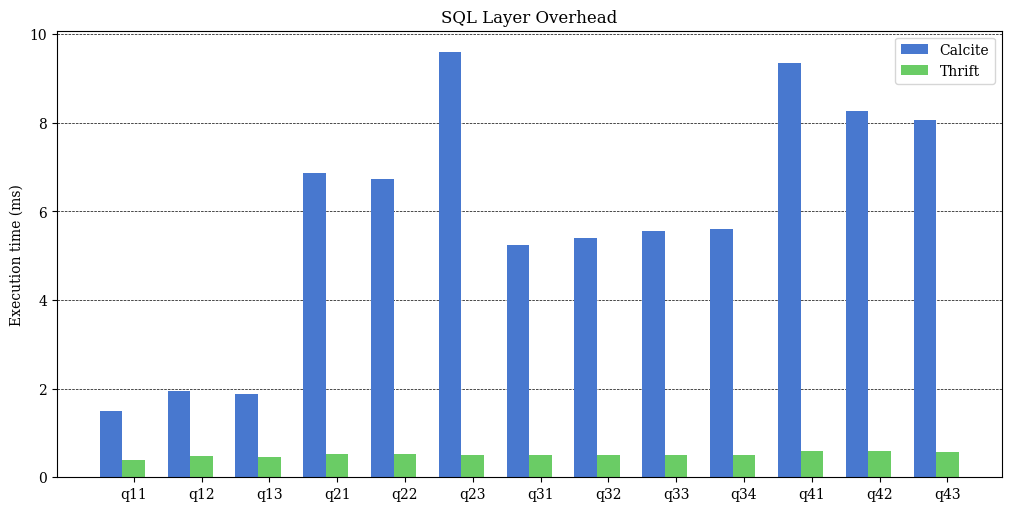

In [198]:
labels_mappings = {
    'calcite_avg': 'Calcite',
    'thrift_avg': 'Thrift',
}
plot_data(comparison_sql_layer, labels_mappings, title='SQL Layer Overhead')

In [199]:
results_fusion_vs_nofusion = pd.DataFrame()
for q in queries:
    fusion_s20_df = pd.read_csv(f'{q}-performance-xpu-fusion-s20.log', header=None, names=['execution_time_ms'])
    nofusion_s20_df = pd.read_csv(f'{q}-performance-xpu-nofusion-s20.log', header=None, names=['execution_time_ms'])

    fusion_s20_cpu_df = pd.read_csv(f'{q}-performance-xpu-fusion-cpu-s20.log', header=None, names=['execution_time_ms'])
    nofusion_s20_cpu_df = pd.read_csv(f'{q}-performance-xpu-nofusion-cpu-s20.log', header=None, names=['execution_time_ms'])

    fusion_segments_s20_df = pd.read_csv(f'{q}-performance-xpu-segments-fusion-s20.log', header=None, names=['execution_time_ms'])
    nofusion_segments_s20_df = pd.read_csv(f'{q}-performance-xpu-segments-nofusion-s20.log', header=None, names=['execution_time_ms'])

    fusion_segments_s20_cpu_df = pd.read_csv(f'{q}-performance-xpu-segments-fusion-cpu-s20.log', header=None, names=['execution_time_ms'])
    nofusion_segments_s20_cpu_df = pd.read_csv(f'{q}-performance-xpu-segments-nofusion-cpu-s20.log', header=None, names=['execution_time_ms'])

    fusion_s100_df = pd.read_csv(f'{q}-performance-xpu-fusion-s100.log', header=None, names=['execution_time_ms'])
    nofusion_s100_df = pd.read_csv(f'{q}-performance-xpu-nofusion-s100.log', header=None, names=['execution_time_ms'])

    fusion_s100_cpu_df = pd.read_csv(f'{q}-performance-xpu-fusion-cpu-s100.log', header=None, names=['execution_time_ms'])
    nofusion_s100_cpu_df = pd.read_csv(f'{q}-performance-xpu-nofusion-cpu-s100.log', header=None, names=['execution_time_ms'])

    fusion_segments_s100_df = pd.read_csv(f'{q}-performance-xpu-segments-fusion-s100.log', header=None, names=['execution_time_ms'])
    nofusion_segments_s100_df = pd.read_csv(f'{q}-performance-xpu-segments-nofusion-s100.log', header=None, names=['execution_time_ms'])

    fusion_segments_s100_cpu_df = pd.read_csv(f'{q}-performance-xpu-segments-fusion-cpu-s100.log', header=None, names=['execution_time_ms'])
    nofusion_segments_s100_cpu_df = pd.read_csv(f'{q}-performance-xpu-segments-nofusion-cpu-s100.log', header=None, names=['execution_time_ms'])

    results_fusion_vs_nofusion[f'{q}_fusion_s20'] = fusion_s20_df['execution_time_ms']
    results_fusion_vs_nofusion[f'{q}_nofusion_s20'] = nofusion_s20_df['execution_time_ms']

    results_fusion_vs_nofusion[f'{q}_fusion_s20_cpu'] = fusion_s20_cpu_df['execution_time_ms']
    results_fusion_vs_nofusion[f'{q}_nofusion_s20_cpu'] = nofusion_s20_cpu_df['execution_time_ms']

    results_fusion_vs_nofusion[f'{q}_fusion_segments_s20'] = fusion_segments_s20_df['execution_time_ms']
    results_fusion_vs_nofusion[f'{q}_nofusion_segments_s20'] = nofusion_segments_s20_df['execution_time_ms']

    results_fusion_vs_nofusion[f'{q}_fusion_segments_s20_cpu'] = fusion_segments_s20_cpu_df['execution_time_ms']
    results_fusion_vs_nofusion[f'{q}_nofusion_segments_s20_cpu'] = nofusion_segments_s20_cpu_df['execution_time_ms']

    results_fusion_vs_nofusion[f'{q}_fusion_s100'] = fusion_s100_df['execution_time_ms']
    results_fusion_vs_nofusion[f'{q}_nofusion_s100'] = nofusion_s100_df['execution_time_ms']

    results_fusion_vs_nofusion[f'{q}_fusion_s100_cpu'] = fusion_s100_cpu_df['execution_time_ms']
    results_fusion_vs_nofusion[f'{q}_nofusion_s100_cpu'] = nofusion_s100_cpu_df['execution_time_ms']

    results_fusion_vs_nofusion[f'{q}_fusion_segments_s100'] = fusion_segments_s100_df['execution_time_ms']
    results_fusion_vs_nofusion[f'{q}_nofusion_segments_s100'] = nofusion_segments_s100_df['execution_time_ms']

    results_fusion_vs_nofusion[f'{q}_fusion_segments_s100_cpu'] = fusion_segments_s100_cpu_df['execution_time_ms']
    results_fusion_vs_nofusion[f'{q}_nofusion_segments_s100_cpu'] = nofusion_segments_s100_cpu_df['execution_time_ms']

/tmp/ipykernel_97181/3576411030.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results_fusion_vs_nofusion[f'{q}_fusion_segments_s20'] = fusion_segments_s20_df['execution_time_ms']
/tmp/ipykernel_97181/3576411030.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results_fusion_vs_nofusion[f'{q}_nofusion_segments_s20'] = nofusion_segments_s20_df['execution_time_ms']
/tmp/ipykernel_97181/3576411030.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, w

In [200]:
comparison_fusion_vs_nofusion = []
for q in queries:
    fusion_times_s20 = results_fusion_vs_nofusion[f'{q}_fusion_s20']
    nofusion_times_s20 = results_fusion_vs_nofusion[f'{q}_nofusion_s20']

    fusion_times_s20_cpu = results_fusion_vs_nofusion[f'{q}_fusion_s20_cpu']
    nofusion_times_s20_cpu = results_fusion_vs_nofusion[f'{q}_nofusion_s20_cpu']

    fusion_times_segments_s20 = results_fusion_vs_nofusion[f'{q}_fusion_segments_s20']
    nofusion_times_segments_s20 = results_fusion_vs_nofusion[f'{q}_nofusion_segments_s20']

    fusion_times_segments_s20_cpu = results_fusion_vs_nofusion[f'{q}_fusion_segments_s20_cpu']
    nofusion_times_segments_s20_cpu = results_fusion_vs_nofusion[f'{q}_nofusion_segments_s20_cpu']

    fusion_times_s100 = results_fusion_vs_nofusion[f'{q}_fusion_s100']
    nofusion_times_s100 = results_fusion_vs_nofusion[f'{q}_nofusion_s100']

    fusion_times_s100_cpu = results_fusion_vs_nofusion[f'{q}_fusion_s100_cpu']
    nofusion_times_s100_cpu = results_fusion_vs_nofusion[f'{q}_nofusion_s100_cpu']

    fusion_times_segments_s100 = results_fusion_vs_nofusion[f'{q}_fusion_segments_s100']
    nofusion_times_segments_s100 = results_fusion_vs_nofusion[f'{q}_nofusion_segments_s100']

    fusion_times_segments_s100_cpu = results_fusion_vs_nofusion[f'{q}_fusion_segments_s100_cpu']
    nofusion_times_segments_s100_cpu = results_fusion_vs_nofusion[f'{q}_nofusion_segments_s100_cpu']

    fusion_s20_avg = fusion_times_s20.min()
    nofusion_s20_avg = nofusion_times_s20.min()

    fusion_s20_cpu_avg = fusion_times_s20_cpu.min()
    nofusion_s20_cpu_avg = nofusion_times_s20_cpu.min()

    fusion_segments_s20_avg = fusion_times_segments_s20.min()
    nofusion_segments_s20_avg = nofusion_times_segments_s20.min()

    fusion_segments_s20_cpu_avg = fusion_times_segments_s20_cpu.min()
    nofusion_segments_s20_cpu_avg = nofusion_times_segments_s20_cpu.min()

    fusion_s100_avg = fusion_times_s100.min()
    nofusion_s100_avg = nofusion_times_s100.min()

    fusion_s100_cpu_avg = fusion_times_s100_cpu.min()
    nofusion_s100_cpu_avg = nofusion_times_s100_cpu.min()

    fusion_segments_s100_avg = fusion_times_segments_s100.min()
    nofusion_segments_s100_avg = nofusion_times_segments_s100.min()

    fusion_segments_s100_cpu_avg = fusion_times_segments_s100_cpu.min()
    nofusion_segments_s100_cpu_avg = nofusion_times_segments_s100_cpu.min()

    comparison_fusion_vs_nofusion.append({
        'query': q,

        'fusion_s20_avg': fusion_s20_avg,
        'nofusion_s20_avg': nofusion_s20_avg,

        'fusion_s20_cpu_avg': fusion_s20_cpu_avg,
        'nofusion_s20_cpu_avg': nofusion_s20_cpu_avg,

        'fusion_segments_s20_avg': fusion_segments_s20_avg,
        'nofusion_segments_s20_avg': nofusion_segments_s20_avg,

        'fusion_segments_s20_cpu_avg': fusion_segments_s20_cpu_avg,
        'nofusion_segments_s20_cpu_avg': nofusion_segments_s20_cpu_avg,

        'fusion_s100_avg': fusion_s100_avg,
        'nofusion_s100_avg': nofusion_s100_avg,

        'fusion_s100_cpu_avg': fusion_s100_cpu_avg,
        'nofusion_s100_cpu_avg': nofusion_s100_cpu_avg,

        'fusion_segments_s100_avg': fusion_segments_s100_avg,
        'nofusion_segments_s100_avg': nofusion_segments_s100_avg,

        'fusion_segments_s100_cpu_avg': fusion_segments_s100_cpu_avg,
        'nofusion_segments_s100_cpu_avg': nofusion_segments_s100_cpu_avg,
    })

comparison_fusion_vs_nofusion = pd.DataFrame(comparison_fusion_vs_nofusion)





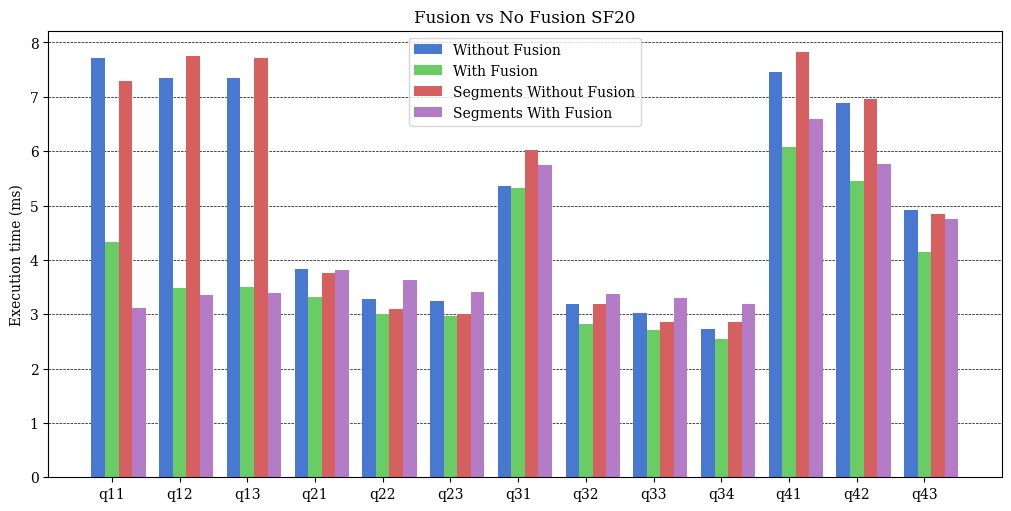

In [201]:
labels_mappings = {
    'nofusion_s20_avg': 'Without Fusion',
    'fusion_s20_avg': 'With Fusion',
    'nofusion_segments_s20_avg': 'Segments Without Fusion',
    'fusion_segments_s20_avg': 'Segments With Fusion',
}
plot_data(comparison_fusion_vs_nofusion, labels_mappings, title='Fusion vs No Fusion SF20')

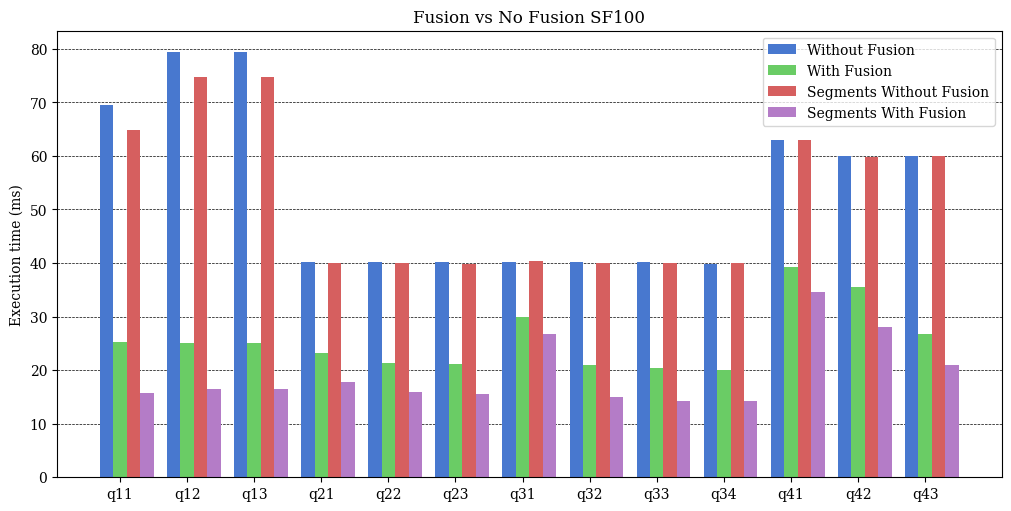

In [202]:
labels_mappings = {
    'nofusion_s100_avg': 'Without Fusion',
    'fusion_s100_avg': 'With Fusion',
    'nofusion_segments_s100_avg': 'Segments Without Fusion',
    'fusion_segments_s100_avg': 'Segments With Fusion',
}
plot_data(comparison_fusion_vs_nofusion, labels_mappings, title='Fusion vs No Fusion SF100')

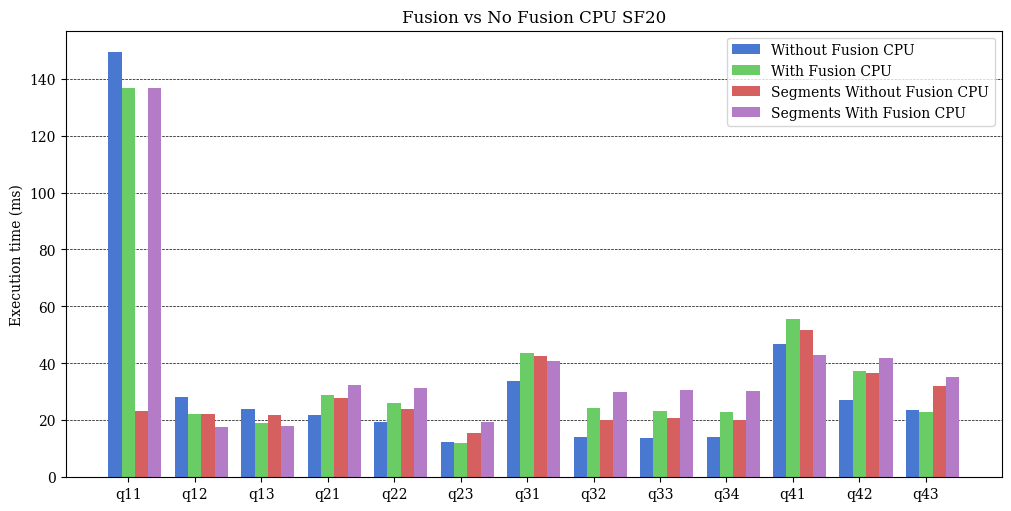

In [203]:
labels_mappings = {
    'nofusion_s20_cpu_avg': 'Without Fusion CPU',
    'fusion_s20_cpu_avg': 'With Fusion CPU',
    'nofusion_segments_s20_cpu_avg': 'Segments Without Fusion CPU',
    'fusion_segments_s20_cpu_avg': 'Segments With Fusion CPU',
}
plot_data(comparison_fusion_vs_nofusion, labels_mappings, title='Fusion vs No Fusion CPU SF20')

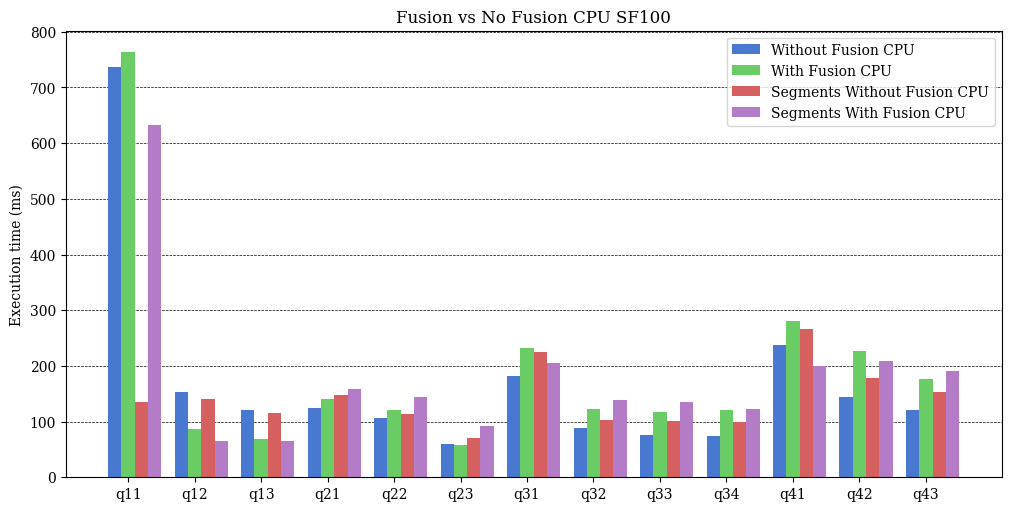

In [204]:
labels_mappings = {
    'nofusion_s100_cpu_avg': 'Without Fusion CPU',
    'fusion_s100_cpu_avg': 'With Fusion CPU',
    'nofusion_segments_s100_cpu_avg': 'Segments Without Fusion CPU',
    'fusion_segments_s100_cpu_avg': 'Segments With Fusion CPU',
}
plot_data(comparison_fusion_vs_nofusion, labels_mappings, title='Fusion vs No Fusion CPU SF100')

In [205]:
results = pd.DataFrame()
for q in queries:
    data_sync = pd.read_csv(f'{q}-performance-sync.log', header=None, names=['execution_time_ms'])
    data_async = pd.read_csv(f'{q}-performance.log', header=None, names=['execution_time_ms'])
    data_fusion = pd.read_csv(f'{q}-performance-fusion.log', header=None, names=['execution_time_ms'])

    data_ddor = pd.read_csv(f'{q}-performance-ddor.log', header=None, names=['execution_time_ms'])
    data_ddor_fusion = pd.read_csv(f'{q}-performance-ddor-fusion.log', header=None, names=['execution_time_ms'])
    data_ddor_1seg = pd.read_csv(f'{q}-performance-ddor-1seg.log', header=None, names=['execution_time_ms'])

    data_heavydb_transformed = pd.read_csv(f'heavydb_perf/transformed/{q}.txt', header=None, names=['execution_time_ms'])
    data_heavydb_original = pd.read_csv(f'heavydb_perf/original/{q}.txt', header=None, names=['execution_time_ms'])

    results[f'{q}_sync'] = data_sync['execution_time_ms']
    results[f'{q}_async'] = data_async['execution_time_ms']
    results[f'{q}_fusion'] = data_fusion['execution_time_ms']

    results[f'{q}_ddor'] = data_ddor['execution_time_ms']
    results[f'{q}_ddor_fusion'] = data_ddor_fusion['execution_time_ms']
    results[f'{q}_ddor_1seg'] = data_ddor_1seg['execution_time_ms']


    results[f'{q}_heavydb_transformed'] = data_heavydb_transformed['execution_time_ms']
    results[f'{q}_heavydb_original'] = data_heavydb_original['execution_time_ms']

results.describe()

/tmp/ipykernel_97181/3333556199.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results[f'{q}_ddor_fusion'] = data_ddor_fusion['execution_time_ms']
/tmp/ipykernel_97181/3333556199.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results[f'{q}_ddor_1seg'] = data_ddor_1seg['execution_time_ms']
/tmp/ipykernel_97181/3333556199.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.

,q11_sync,q11_async,q11_fusion,q11_ddor,q11_ddor_fusion,q11_ddor_1seg,q11_heavydb_transformed,q11_heavydb_original,q12_sync,q12_async,...,q42_heavydb_transformed,q42_heavydb_original,q43_sync,q43_async,q43_fusion,q43_ddor,q43_ddor_fusion,q43_ddor_1seg,q43_heavydb_transformed,q43_heavydb_original
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,13.066991,12.740236,13.988446,14.620223,9.450162,9.830411,18.020000,14.590000,14.023130,13.684812,...,52.390000,50.470000,14.213607,12.481374,15.053533,13.360693,93.172927,17.884246,54.940000,66.120000
std,0.058390,0.184307,12.849264,26.183252,16.584807,15.897694,5.508451,4.114755,0.072740,0.175961,...,16.095608,14.940593,1.048972,0.903446,9.871079,0.260600,94.455202,32.064517,85.361006,82.694189
min,13.007900,12.659700,8.117700,11.817800,4.350770,7.119990,11.000000,11.000000,13.943600,13.607900,...,44.000000,45.000000,12.864300,11.603900,9.931090,12.996500,8.285610,10.339100,41.000000,52.000000
25%,13.040025,12.678350,8.605775,11.969600,4.603455,7.247930,13.750000,12.000000,13.989675,13.630175,...,45.000000,45.000000,13.154550,11.771575,11.486375,13.158050,8.685177,10.493350,43.000000,53.000000
50%,13.056750,12.687000,8.764440,11.991800,6.298060,7.288360,17.500000,13.000000,14.008150,13.637250,...,53.000000,46.000000,14.339450,12.058800,12.384700,13.422050,9.075500,10.677150,46.000000,57.000000
75%,13.074275,12.704500,8.957413,12.028850,6.646415,7.335085,21.000000,17.000000,14.038375,13.646550,...,55.000000,53.000000,14.808900,13.134150,12.933650,13.475625,187.992750,10.915450,51.000000,62.000000
max,13.519900,14.070100,67.230100,273.833000,109.150000,144.532000,43.000000,44.000000,14.484600,15.004200,...,204.000000,191.000000,17.193600,15.427900,51.903100,15.117100,246.409000,205.800000,899.000000,883.000000


In [206]:
comparison = []

for q in queries:
    sync_avg = results[f'{q}_sync'].mean()
    async_avg = results[f'{q}_async'].mean()
    fusion_avg = results[results[f'{q}_fusion'] < 20.0][f'{q}_fusion'].mean()
    ddor_avg = results[results[f'{q}_ddor'] < 20.0][f'{q}_ddor'].mean()
    ddor_fusion_avg = results[results[f'{q}_ddor_fusion'] < 20.0][f'{q}_ddor_fusion'].mean()
    ddor_1seg_avg = results[results[f'{q}_ddor_1seg'] < 20.0][f'{q}_ddor_1seg'].mean()

    heavydb_transformed_avg = results[1:][f'{q}_heavydb_transformed'].mean()
    heavydb_original_avg = results[1:][f'{q}_heavydb_original'].mean()
    speedup_async = (sync_avg - async_avg) / sync_avg
    speedup_fusion = (sync_avg - fusion_avg) / sync_avg
    fusion_async = (async_avg - fusion_avg) / async_avg
    heavydb_original_async = (async_avg - heavydb_original_avg) / async_avg
    heavydb_transformed_async = (async_avg - heavydb_transformed_avg) / async_avg
    # print(f'{q}: Sync avg = {sync_avg:5.2f} ms, Async avg = {async_avg:5.2f} ms, Fusion avg = {fusion_avg:5.2f} ms, Speedup async on sync = {speedup_async:6.2%}, Speedup fusion on sync = {speedup_fusion:6.2%}')

    comparison.append({
        'query': q,
        'sync_avg': sync_avg,
        'async_avg': async_avg,
        'fusion_avg': fusion_avg,

        'ddor_avg': ddor_avg,
        'ddor_fusion_avg': ddor_fusion_avg,
        'ddor_1seg_avg': ddor_1seg_avg,

        'heavydb_transformed_avg': heavydb_transformed_avg,
        'heavydb_original_avg': heavydb_original_avg,
        
        'async_sync': speedup_async * 100,
        'fusion_sync': speedup_fusion * 100,
        'fusion_async': fusion_async * 100,
        'heavydb_original_async': heavydb_original_async * 100,
        'heavydb_transformed_async': heavydb_transformed_async * 100,
    })

comparison = pd.DataFrame(comparison)
# comparison.set_index('query', inplace=True)
comparison

,query,sync_avg,async_avg,fusion_avg,ddor_avg,ddor_fusion_avg,ddor_1seg_avg,heavydb_transformed_avg,heavydb_original_avg,async_sync,fusion_sync,fusion_async,heavydb_original_async,heavydb_transformed_async
0,q11,13.066991,12.740236,8.739595,12.001912,5.798595,7.301964,17.767677,14.292929,2.500614,33.117005,31.401624,-12.187320,-39.461127
1,q12,14.023130,13.684812,9.085047,12.879705,6.121062,8.516530,14.717172,14.666667,2.412571,35.213846,33.612193,-7.174776,-7.543836
2,q13,13.997501,13.627748,8.856918,12.565472,5.920466,8.526252,13.232323,14.525253,2.641564,36.725009,35.008208,-6.585861,2.901615
3,q21,12.816319,12.031894,11.843347,13.646247,11.499407,11.180511,31.010101,29.818182,6.120517,7.591668,1.567063,-147.826168,-157.732498
4,q22,10.199652,9.333765,8.835067,11.505088,8.180138,7.974831,29.919192,31.898990,8.489377,13.378743,5.342950,-241.759071,-220.547931
5,q23,8.615798,7.784594,6.193019,7.706031,5.120477,7.282293,29.545455,28.696970,9.647448,28.120191,20.445181,-268.637989,-279.537529
6,q31,15.705098,14.747863,13.718777,14.884217,12.701189,13.358249,31.313131,27.555556,6.095059,12.647621,6.977867,-86.844396,-112.323177
7,q32,10.701047,9.443966,9.004991,11.624402,8.161425,8.465336,53.353535,51.707071,11.747272,15.849438,4.648203,-447.514391,-464.948430
8,q33,9.606535,8.106762,7.584868,8.400735,6.017290,7.754491,51.151515,49.000000,15.612004,21.044701,6.437760,-504.433667,-530.973426
9,q34,9.371616,7.872036,7.741775,8.169958,5.884066,7.724434,52.707071,51.797980,16.001298,17.391256,1.654738,-557.999775,-569.548133


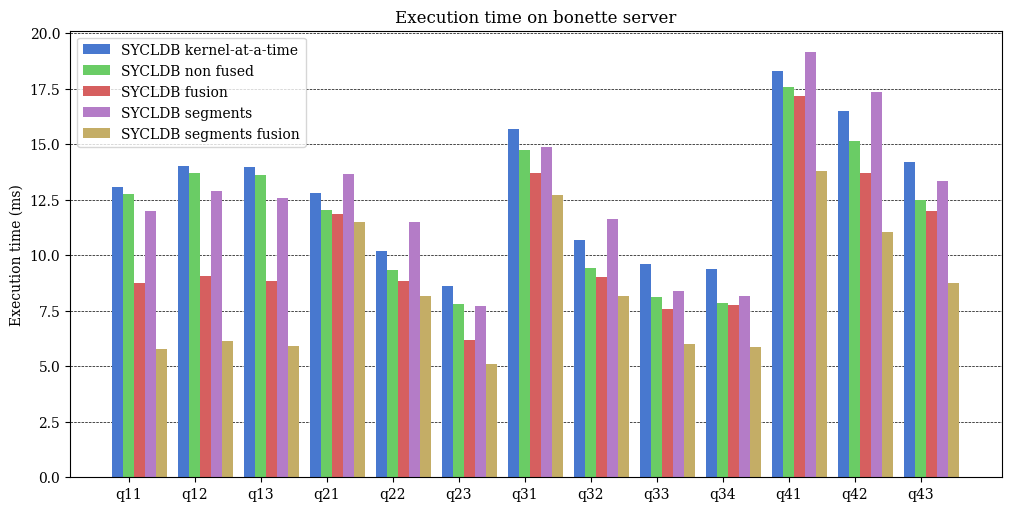

In [207]:
labels_mapping = {
    # 'heavydb_original_avg': 'HeavyDB',
    'sync_avg': 'SYCLDB kernel-at-a-time',
    'async_avg': 'SYCLDB non fused',
    'fusion_avg': 'SYCLDB fusion',
    'ddor_avg': 'SYCLDB segments',
    'ddor_fusion_avg': 'SYCLDB segments fusion',
}

plot_data(comparison, labels_mapping, title='Execution time on bonette server')

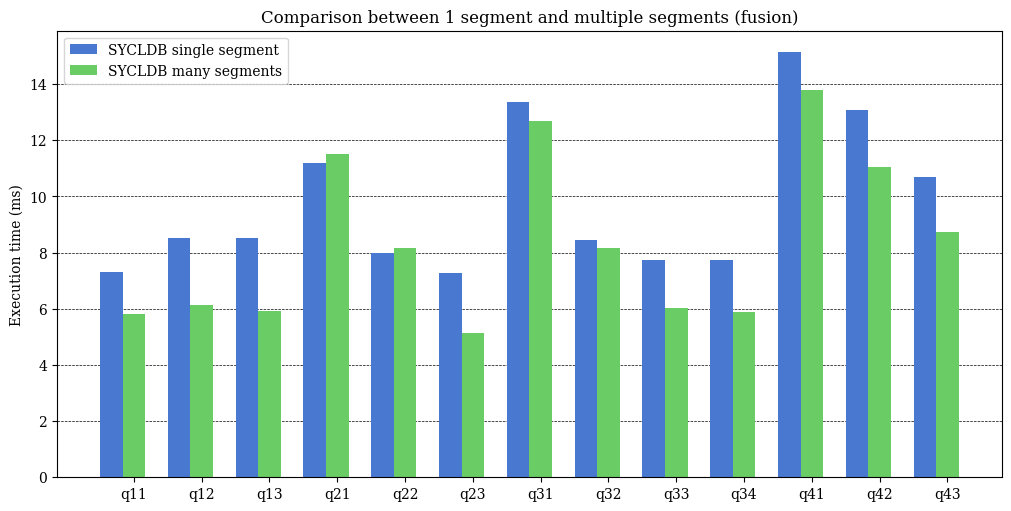

In [208]:
labels_mapping = {
    'ddor_1seg_avg': 'SYCLDB single segment',
    'ddor_fusion_avg': 'SYCLDB many segments',
}

plot_data(comparison, labels_mapping, title='Comparison between 1 segment and multiple segments (fusion)')

In [209]:
results_cxl = pd.DataFrame()

query_times_crystal = defaultdict(list)

with open('crystal/results.txt') as f:
    for line in f:
        query, time = line.split(': ')
        assert f'q{query}' in queries
        query_times_crystal[f'q{query}'].append(float(time))

for q in queries:
    sync_df = pd.read_csv(f'{q}-performance-sync-cxl.log', header=None, names=['execution_time_ms'])
    async_df = pd.read_csv(f'{q}-performance-async-cxl.log', header=None, names=['execution_time_ms'])
    fusion_df = pd.read_csv(f'{q}-performance-cxl.log', header=None, names=['execution_time_ms'])
    ddor_df = pd.read_csv(f'{q}-performance-ddor-l40.log', header=None, names=['execution_time_ms'])
    ddor_fusion_df = pd.read_csv(f'{q}-performance-segments-cxl-fusion-s20.log', header=None, names=['execution_time_ms'])
    heavydb_df = pd.read_csv(f'heavydb_perf/cxl_server/{q}.txt', header=None, names=['execution_time_ms'])

    results_cxl[f'{q}_sync'] = sync_df['execution_time_ms']
    results_cxl[f'{q}_async'] = async_df['execution_time_ms']
    results_cxl[f'{q}_fusion'] = fusion_df['execution_time_ms']
    results_cxl[f'{q}_ddor'] = ddor_df['execution_time_ms']
    results_cxl[f'{q}_ddor_fusion'] = ddor_fusion_df['execution_time_ms']
    results_cxl[f'{q}_crystal'] = query_times_crystal[q]
    results_cxl[f'{q}_heavydb'] = heavydb_df['execution_time_ms']

results_cxl.describe()

,q11_sync,q11_async,q11_fusion,q11_ddor,q11_ddor_fusion,q11_crystal,q11_heavydb,q12_sync,q12_async,q12_fusion,...,q42_ddor_fusion,q42_crystal,q42_heavydb,q43_sync,q43_async,q43_fusion,q43_ddor,q43_ddor_fusion,q43_crystal,q43_heavydb
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,7.336749,6.950151,4.937993,10.540893,12.501739,2.561560,59.24000,7.480610,7.138039,4.165261,...,104.350822,4.390494,42.810000,6.958989,5.160976,12.794509,5.823720,94.268461,4.735919,38.430000
std,0.211763,0.018197,6.836804,4.452602,31.693442,0.020717,9.57387,0.037796,0.015252,7.044130,...,146.431308,0.040548,30.369674,0.150585,0.104624,27.730896,1.559775,150.987725,0.737159,2.871859
min,7.265460,6.908720,4.019400,7.344420,3.207750,2.555970,21.00000,7.424670,7.103940,3.348460,...,6.149680,4.351780,28.000000,6.833180,4.964030,3.780820,4.854610,3.664890,4.566940,28.000000
25%,7.299835,6.940392,4.076265,7.908425,3.561463,2.558393,55.00000,7.465530,7.130800,3.381823,...,7.978680,4.372357,40.000000,6.899707,5.136178,3.870893,5.159538,4.673160,4.623223,38.000000
50%,7.310225,6.947635,4.229905,7.971005,3.882275,2.559360,57.50000,7.478720,7.137390,3.393810,...,9.047020,4.378145,40.000000,6.934425,5.174730,3.994200,5.206475,8.533285,4.636400,39.000000
75%,7.321115,6.957540,4.397405,14.021850,5.358420,2.560245,63.00000,7.487570,7.142658,3.477768,...,271.626750,4.390867,40.000000,6.964735,5.197740,4.039580,5.261180,262.913750,4.656040,39.000000
max,9.391660,7.075760,72.599500,19.389400,171.124000,2.765820,93.00000,7.805730,7.239370,73.885200,...,484.580000,4.672350,342.000000,8.202850,5.964000,121.456000,12.362800,562.167000,11.831500,52.000000


note on the above: fusion std also takes in consideration when the JIT if the fusion happens, which has way higher execution times. When making plots, we filter out those cases.

In [210]:
comparison_cxl = []

for q in queries:
    sync_avg = results_cxl[f'{q}_sync'].mean()
    async_avg = results_cxl[f'{q}_async'].mean()
    fusion_avg = results_cxl[f'{q}_fusion'].min()
    ddor_avg = results_cxl[f'{q}_ddor'].min()
    ddor_fusion_avg = results_cxl[f'{q}_ddor_fusion'].min()
    crystal_avg = results_cxl[f'{q}_crystal'].min()
    heavydb_avg = results_cxl[f'{q}_heavydb'].min()

    speedup_async = (sync_avg - async_avg) / sync_avg
    speedup_fusion = (sync_avg - fusion_avg) / sync_avg
    fusion_async = (async_avg - fusion_avg) / async_avg

    comparison_cxl.append({
        'query': q,
        'sync_avg': sync_avg,
        'async_avg': async_avg,
        'fusion_avg': fusion_avg,
        'ddor_avg': ddor_avg,
        'ddor_fusion_avg': ddor_fusion_avg,
        'crystal_avg': crystal_avg,
        'heavydb_avg': heavydb_avg,
        'async_sync': speedup_async * 100,
        'fusion_sync': speedup_fusion * 100,
        'fusion_async': fusion_async * 100,
    })

comparison_cxl = pd.DataFrame(comparison_cxl)
comparison_cxl

,query,sync_avg,async_avg,fusion_avg,ddor_avg,ddor_fusion_avg,crystal_avg,heavydb_avg,async_sync,fusion_sync,fusion_async
0,q11,7.336749,6.950151,4.01940,7.34442,3.20775,2.55597,21,5.269335,45.215520,42.168167
1,q12,7.480610,7.138039,3.34846,7.62360,2.98169,2.55722,23,4.579461,55.238144,53.089915
2,q13,7.483421,7.108058,3.22611,7.55337,3.71874,2.56205,26,5.015932,56.889906,54.613342
3,q21,5.611103,3.984008,3.57665,5.04134,3.58400,2.81914,24,28.997785,36.257635,10.224822
4,q22,4.242118,3.817336,2.73761,3.92956,2.58047,2.80611,16,10.013446,35.465963,28.284800
5,q23,3.986156,3.468662,2.70953,3.34203,2.25116,2.83517,16,12.982283,32.026489,21.885435
6,q31,6.089624,5.596906,5.44340,6.94020,5.69956,2.89466,17,8.091096,10.611882,2.742701
7,q32,4.540167,3.533796,2.79669,4.20521,2.57728,3.04467,31,22.165960,38.401171,20.858755
8,q33,4.553606,3.531522,2.75944,3.37191,2.08922,3.07770,40,22.445587,39.400993,21.862594
9,q34,4.286777,3.005747,2.49256,3.27001,2.02934,3.08909,39,29.883278,41.854681,17.073534


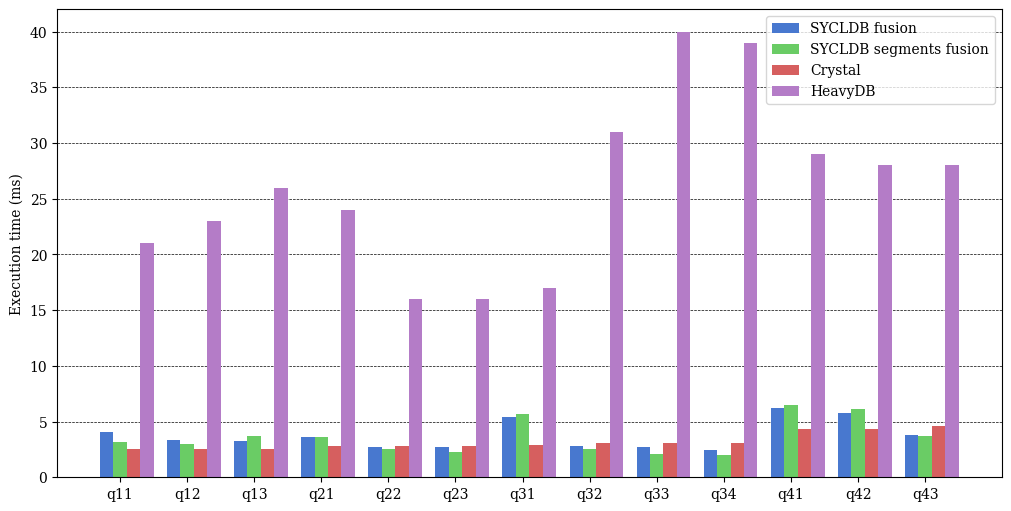

In [211]:
labels_mapping = {
    # 'sync_avg': 'SYCLDB kernel-at-a-time',
    # 'async_avg': 'SYCLDB non fused',
    'fusion_avg': 'SYCLDB fusion',
    # 'ddor_avg': 'SYCLDB segments',
    'ddor_fusion_avg': 'SYCLDB segments fusion',
    'crystal_avg': 'Crystal',
    'heavydb_avg': 'HeavyDB',
}

plot_data(comparison_cxl, labels_mapping, title='')

In [212]:
host_results = pd.DataFrame()

for q in queries:
    numa0_df = pd.read_csv(f'{q}-performance-cxl-numa-0.log', header=None, names=['execution_time_ms'])
    numa1_df = pd.read_csv(f'{q}-performance-cxl-numa-1.log', header=None, names=['execution_time_ms'])
    numa2_df = pd.read_csv(f'{q}-performance-cxl-numa-2.log', header=None, names=['execution_time_ms'])

    bonette_df = pd.read_csv(f'{q}-performance-host-bonette-sf20.log', header=None, names=['execution_time_ms'])

    xpu_df = pd.read_csv(f'{q}-performance-host-xpu-sf20.log', header=None, names=['execution_time_ms'])

    host_results[f'{q}_gpu_memory'] = results_cxl[f'{q}_async']
    host_results[f'{q}_numa_0'] = numa0_df['execution_time_ms']
    host_results[f'{q}_numa_1'] = numa1_df['execution_time_ms']
    host_results[f'{q}_numa_2'] = numa2_df['execution_time_ms']

    host_results[f'{q}_bonette'] = bonette_df['execution_time_ms']

    host_results[f'{q}_xpu'] = xpu_df['execution_time_ms']

host_results.describe()

,q11_gpu_memory,q11_numa_0,q11_numa_1,q11_numa_2,q11_bonette,q11_xpu,q12_gpu_memory,q12_numa_0,q12_numa_1,q12_numa_2,...,q42_numa_1,q42_numa_2,q42_bonette,q42_xpu,q43_gpu_memory,q43_numa_0,q43_numa_1,q43_numa_2,q43_bonette,q43_xpu
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,6.950151,318.306590,273.049860,464.140530,297.168650,154.200120,7.138039,376.272150,225.244270,444.699620,...,361.613720,632.556150,517.402470,247.95334,5.160976,341.358260,299.736290,483.115480,696.643800,293.510560
std,0.018197,76.424709,59.610625,14.335661,1.486248,0.995828,0.015252,6.382141,7.173372,17.402467,...,24.059826,11.814545,3.806178,1.62965,0.104624,13.889173,1.740888,7.069451,3.809598,3.253082
min,6.908720,234.079000,232.263000,424.068000,292.657000,153.702000,7.103940,366.700000,220.188000,417.533000,...,351.991000,612.644000,513.245000,244.24200,4.964030,298.606000,299.031000,469.112000,692.546000,287.566000
25%,6.940392,236.069000,234.040000,453.522250,296.407500,153.989750,7.130800,370.080500,222.303000,423.001000,...,354.007000,621.372750,515.123250,246.88600,5.136178,338.511250,299.171250,477.018250,694.139250,291.428000
50%,6.947635,383.992000,236.248500,464.913500,297.079000,154.050000,7.137390,373.765500,223.016500,446.310500,...,355.123500,632.004500,516.382000,248.10800,5.174730,339.884000,299.345500,483.484000,695.655500,293.240000
75%,6.957540,386.875500,352.466500,478.057500,297.812000,154.131000,7.142658,382.369750,224.465750,457.029000,...,358.094500,640.724250,518.310500,248.98375,5.197740,353.330500,299.650750,486.433500,697.435250,295.340750
max,7.075760,407.071000,395.053000,489.245000,306.834000,163.476000,7.239370,390.848000,264.362000,474.223000,...,489.815000,655.973000,537.017000,252.07200,5.964000,358.399000,311.198000,502.132000,712.337000,304.606000


In [213]:
comparison_host = []

for q in queries:
    gpu_memory_avg = host_results[f'{q}_gpu_memory'].mean()
    numa_0_avg = host_results[f'{q}_numa_0'].mean()
    numa_1_avg = host_results[f'{q}_numa_1'].mean()
    numa_2_avg = host_results[f'{q}_numa_2'].mean()

    bonette_avg = host_results[f'{q}_bonette'].mean()

    xpu_avg = host_results[f'{q}_xpu'].mean()

    comparison_host.append({
        'query': q,
        'gpu_memory_avg': gpu_memory_avg,
        'numa_0_avg': numa_0_avg,
        'numa_1_avg': numa_1_avg,
        'numa_2_avg': numa_2_avg,

        'bonette_avg': bonette_avg,

        'xpu_avg': xpu_avg,
    })

comparison_host = pd.DataFrame(comparison_host)
comparison_host

,query,gpu_memory_avg,numa_0_avg,numa_1_avg,numa_2_avg,bonette_avg,xpu_avg
0,q11,6.950151,318.30659,273.04986,464.14053,297.16865,154.20012
1,q12,7.138039,376.27215,225.24427,444.69962,325.39313,170.32490
2,q13,7.108058,366.73850,233.63129,454.54244,324.50433,169.79504
3,q21,3.984008,395.52294,415.53723,567.41775,753.26494,353.67974
4,q22,3.817336,368.47590,381.30539,515.46220,647.88111,287.01114
5,q23,3.468662,272.22182,278.05195,387.48363,601.75229,263.00929
6,q31,5.596906,376.45534,416.88774,518.73857,561.37639,318.88417
7,q32,3.533796,122.17737,119.25486,169.81803,252.74682,112.88258
8,q33,3.531522,104.55027,104.66985,141.01519,223.80077,100.26256
9,q34,3.005747,107.54815,104.27973,141.15548,223.68467,100.11969


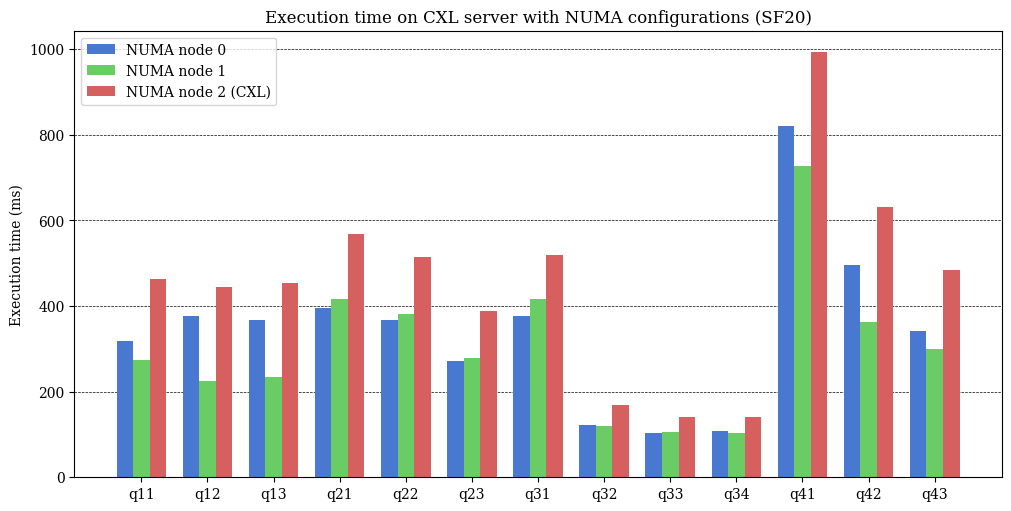

In [214]:
labels_mapping = {
    # 'gpu_memory_avg': 'SYCLDB GPU',
    'numa_0_avg': 'NUMA node 0',
    'numa_1_avg': 'NUMA node 1',
    'numa_2_avg': 'NUMA node 2 (CXL)',
}

plot_data(comparison_host, labels_mapping, title='Execution time on CXL server with NUMA configurations (SF20)')

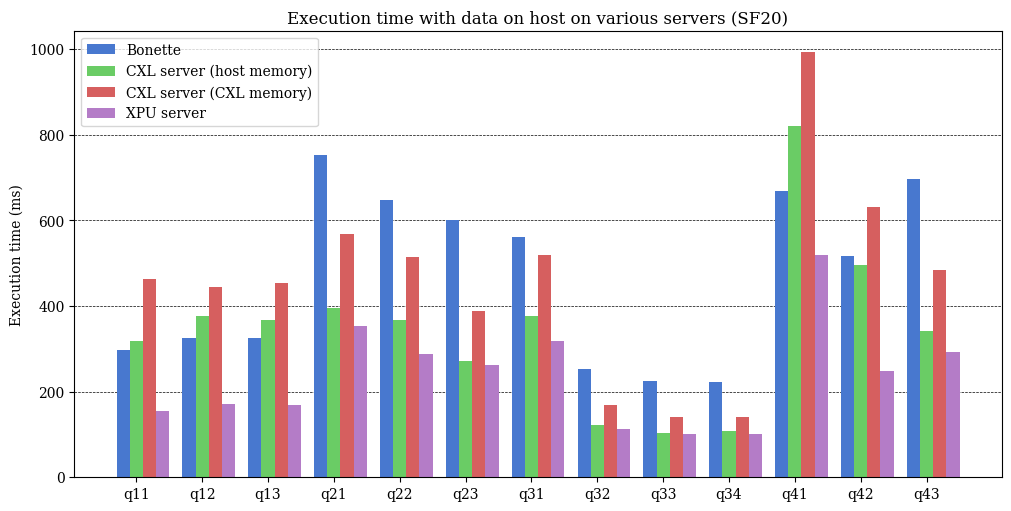

In [215]:
labels_mapping = {
    'bonette_avg': 'Bonette',
    'numa_0_avg': 'CXL server (host memory)',
    'numa_2_avg': 'CXL server (CXL memory)',
    'xpu_avg': 'XPU server',
}

plot_data(comparison_host, labels_mapping, title='Execution time with data on host on various servers (SF20)')

In [216]:
cpu_results = pd.DataFrame()
duckdb_results_s20 = pd.read_csv('results_duckdb_s20.csv')
duckdb_results_s100 = pd.read_csv('results_duckdb_s100.csv')
duckdb_results_s160 = pd.read_csv('results_duckdb_s160.csv')
duckdb_results_s250 = pd.read_csv('results_duckdb_s250.csv')
duckdb_results_s500 = pd.read_csv('results_duckdb_s500.csv')
duckdb_results_s1000 = pd.read_csv('results_duckdb_s1000.csv')

duckdb_results_s20_bonette = pd.read_csv('results_duckdb_s20_bonette.csv')
duckdb_results_s40_bonette = pd.read_csv('results_duckdb_s40_bonette.csv')
duckdb_results_s100_bonette = pd.read_csv('results_duckdb_s100_bonette.csv')
duckdb_results_s160_bonette = pd.read_csv('results_duckdb_s160_bonette.csv')

duckdb_results_s20_xpu = pd.read_csv('results_duckdb_s20_xpu.csv')
duckdb_results_s100_xpu = pd.read_csv('results_duckdb_s100_xpu.csv')


for q in queries:
    cpu_s20_df = pd.read_csv(f'{q}-performance-cxl-cpu-s20.log', header=None, names=['execution_time_ms'])
    cpu_s100_df = pd.read_csv(f'{q}-performance-cxl-cpu-s100.log', header=None, names=['execution_time_ms'])
    cpu_s160_df = pd.read_csv(f'{q}-performance-cxl-cpu-s160.log', header=None, names=['execution_time_ms'])
    cpu_s160_2_df = pd.read_csv(f'{q}-performance-cxl-cpu-s160.log-2', header=None, names=['execution_time_ms'])
    cpu_s250_df = pd.read_csv(f'{q}-performance-cxl-cpu-s250.log', header=None, names=['execution_time_ms'])

    mordred_s160_df = pd.read_csv(f'{q}-mordred-s160.log', header=None, names=['execution_time_ms'])
    mordred_s160_2_df = pd.read_csv(f'{q}-mordred-s160.log-2', header=None, names=['execution_time_ms'])

    mordred_s40_bonette_df = pd.read_csv(f'{q}-mordred-s40-bonette.log', header=None, names=['execution_time_ms'])
    mordred_s160_bonette_df = pd.read_csv(f'{q}-mordred-s160-bonette.log', header=None, names=['execution_time_ms'])

    cpu_s20_bonette_df = pd.read_csv(f'{q}-performance-cpu-s20.log', header=None, names=['execution_time_ms'])
    cpu_s40_bonette_df = pd.read_csv(f'{q}-performance-cpu-s40.log', header=None, names=['execution_time_ms'])
    cpu_s100_bonette_df = pd.read_csv(f'{q}-performance-cpu-s100.log', header=None, names=['execution_time_ms'])
    cpu_s160_bonette_df = pd.read_csv(f'{q}-performance-cpu-s160.log', header=None, names=['execution_time_ms'])

    cpu_results[f'{q}_cpu_s20'] = cpu_s20_df['execution_time_ms']
    cpu_results[f'{q}_cpu_s100'] = cpu_s100_df['execution_time_ms']
    cpu_results[f'{q}_cpu_s160'] = cpu_s160_df['execution_time_ms']
    cpu_results[f'{q}_cpu_s160_2'] = cpu_s160_2_df['execution_time_ms']
    cpu_results[f'{q}_cpu_s250'] = cpu_s250_df['execution_time_ms']

    cpu_results[f'{q}_mordred_s160'] = mordred_s160_df['execution_time_ms']
    cpu_results[f'{q}_mordred_s160_2'] = mordred_s160_2_df['execution_time_ms']

    cpu_results[f'{q}_mordred_s40_bonette'] = mordred_s40_bonette_df['execution_time_ms']
    cpu_results[f'{q}_mordred_s160_bonette'] = mordred_s160_bonette_df['execution_time_ms']

    cpu_results[f'{q}_cpu_s20_bonette'] = cpu_s20_bonette_df['execution_time_ms']
    cpu_results[f'{q}_cpu_s40_bonette'] = cpu_s40_bonette_df['execution_time_ms']
    cpu_results[f'{q}_cpu_s100_bonette'] = cpu_s100_bonette_df['execution_time_ms']
    cpu_results[f'{q}_cpu_s160_bonette'] = cpu_s160_bonette_df['execution_time_ms']

    cpu_results[f'{q}_cpu_s20_xpu'] = results_fusion_vs_nofusion[f'{q}_nofusion_segments_s20_cpu']
    cpu_results[f'{q}_cpu_s100_xpu'] = results_fusion_vs_nofusion[f'{q}_nofusion_segments_s100_cpu']

    cpu_results[f'{q}_duckdb_s20'] = duckdb_results_s20[q]
    cpu_results[f'{q}_duckdb_s100'] = duckdb_results_s100[q]
    cpu_results[f'{q}_duckdb_s160'] = duckdb_results_s160[q]
    cpu_results[f'{q}_duckdb_s250'] = duckdb_results_s250[q]
    cpu_results[f'{q}_duckdb_s500'] = duckdb_results_s500[q]
    cpu_results[f'{q}_duckdb_s1000'] = duckdb_results_s1000[q]

    cpu_results[f'{q}_duckdb_s20_bonette'] = duckdb_results_s20_bonette[q]
    cpu_results[f'{q}_duckdb_s40_bonette'] = duckdb_results_s40_bonette[q]
    cpu_results[f'{q}_duckdb_s100_bonette'] = duckdb_results_s100_bonette[q]
    cpu_results[f'{q}_duckdb_s160_bonette'] = duckdb_results_s160_bonette[q]

    cpu_results[f'{q}_duckdb_s20_xpu'] = duckdb_results_s20_xpu[q]
    cpu_results[f'{q}_duckdb_s100_xpu'] = duckdb_results_s100_xpu[q]

cpu_results[1:].describe()

/tmp/ipykernel_97181/2780735217.py:60: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cpu_results[f'{q}_duckdb_s500'] = duckdb_results_s500[q]
/tmp/ipykernel_97181/2780735217.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cpu_results[f'{q}_duckdb_s1000'] = duckdb_results_s1000[q]
/tmp/ipykernel_97181/2780735217.py:63: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) i

,q11_cpu_s20,q11_cpu_s100,q11_cpu_s160,q11_cpu_s160_2,q11_cpu_s250,q11_mordred_s160,q11_mordred_s160_2,q11_mordred_s40_bonette,q11_mordred_s160_bonette,q11_cpu_s20_bonette,...,q43_duckdb_s160,q43_duckdb_s250,q43_duckdb_s500,q43_duckdb_s1000,q43_duckdb_s20_bonette,q43_duckdb_s40_bonette,q43_duckdb_s100_bonette,q43_duckdb_s160_bonette,q43_duckdb_s20_xpu,q43_duckdb_s100_xpu
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,...,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,323.306788,974.257000,1334.989091,1219.149495,2264.491313,85.240603,75.442199,80.079422,370.701111,126.894737,...,428.352669,583.029985,994.348107,2286.750984,126.659745,273.505924,594.355680,974.067563,43.819594,185.381410
std,9.301152,14.633729,138.230294,80.379342,67.337359,7.850522,0.449824,0.572978,17.752780,1.917171,...,101.597183,177.794691,401.515438,910.827358,1.759141,3.021107,8.491578,13.444414,1.025764,9.722412
min,313.095000,953.558000,1230.090000,1140.380000,2186.010000,82.292600,73.226700,79.261300,312.864000,125.306000,...,309.827089,403.534174,550.779581,987.729311,123.287916,267.377377,577.255487,947.754145,41.676998,168.573380
25%,317.601500,964.912500,1274.835000,1176.840000,2225.855000,83.611450,75.164750,79.763900,375.189500,125.788000,...,376.597881,484.984636,754.636168,1603.173375,125.421643,271.333575,588.427186,963.291764,43.176413,178.548336
50%,320.447000,971.298000,1291.680000,1200.370000,2248.890000,84.057200,75.458100,79.960600,376.260000,126.245000,...,410.015583,522.533894,830.235958,1941.719294,126.641989,273.122787,592.079878,971.977949,43.753386,183.429003
75%,325.335500,978.706000,1323.765000,1224.765000,2268.820000,84.778500,75.757450,80.163350,376.956500,127.309500,...,443.932533,590.595841,1082.841396,3000.156522,127.788186,275.316358,600.695014,981.929898,44.257998,190.842867
max,368.160000,1029.420000,1830.560000,1539.430000,2587.170000,140.801000,76.529900,82.581100,378.929000,138.078000,...,917.894125,1279.889107,2379.565716,4545.185089,131.302834,283.200264,622.029305,1012.542009,46.953440,219.141960


In [217]:
comparison_cpu = []

for q in queries:
    cpu_s20_avg = cpu_results[f'{q}_cpu_s20'][1:].mean()
    cpu_s100_avg = cpu_results[f'{q}_cpu_s100'][1:].mean()
    cpu_s160_avg = cpu_results[f'{q}_cpu_s160'][1:].mean()
    cpu_s160_std = cpu_results[f'{q}_cpu_s160'][1:].std()
    cpu_s160_2_avg = cpu_results[f'{q}_cpu_s160_2'][1:].mean()
    cpu_s160_2_std = cpu_results[f'{q}_cpu_s160_2'][1:].std()
    cpu_s250_avg = cpu_results[f'{q}_cpu_s250'][1:].mean()

    mordred_s160_avg = cpu_results[f'{q}_mordred_s160'][1:].mean()
    mordred_s160_std = cpu_results[f'{q}_mordred_s160'][1:].std()
    mordred_s160_2_avg = cpu_results[f'{q}_mordred_s160_2'][1:].mean()
    mordred_s160_2_std = cpu_results[f'{q}_mordred_s160_2'][1:].std()

    mordred_s40_bonette_avg = cpu_results[f'{q}_mordred_s40_bonette'][1:].mean()
    mordred_s40_bonette_std = cpu_results[f'{q}_mordred_s40_bonette'][1:].std()
    mordred_s160_bonette_avg = cpu_results[f'{q}_mordred_s160_bonette'][1:].mean()
    mordred_s160_bonette_std = cpu_results[f'{q}_mordred_s160_bonette'][1:].std()

    cpu_s20_bonette_avg = cpu_results[f'{q}_cpu_s20_bonette'][1:].mean()
    cpu_s40_bonette_avg = cpu_results[f'{q}_cpu_s40_bonette'][1:].mean()
    cpu_s40_bonette_std = cpu_results[f'{q}_cpu_s40_bonette'][1:].std()
    cpu_s100_bonette_avg = cpu_results[f'{q}_cpu_s100_bonette'][1:].mean()
    cpu_s160_bonette_avg = cpu_results[f'{q}_cpu_s160_bonette'][1:].mean()
    cpu_s160_bonette_std = cpu_results[f'{q}_cpu_s160_bonette'][1:].std()

    cpu_s20_xpu_avg = cpu_results[f'{q}_cpu_s20_xpu'][1:].mean()
    cpu_s20_xpu_std = cpu_results[f'{q}_cpu_s20_xpu'][1:].std()
    cpu_s100_xpu_avg = cpu_results[f'{q}_cpu_s100_xpu'][1:].mean()
    cpu_s100_xpu_std = cpu_results[f'{q}_cpu_s100_xpu'][1:].std()

    duckdb_avg = cpu_results[f'{q}_duckdb_s20'][1:].mean()
    duckdb_s100_avg = cpu_results[f'{q}_duckdb_s100'][1:].mean()
    duckdb_s160_avg = cpu_results[f'{q}_duckdb_s160'][1:].mean()
    duckdb_s160_std = cpu_results[f'{q}_duckdb_s160'][1:].std()
    duckdb_s250_avg = cpu_results[f'{q}_duckdb_s250'][1:].mean()
    duckdb_s500_avg = cpu_results[f'{q}_duckdb_s500'][1:].mean()
    duckdb_s1000_avg = cpu_results[f'{q}_duckdb_s1000'][1:].mean()

    duckdb_s20_bonette_avg = cpu_results[f'{q}_duckdb_s20_bonette'][1:].mean()
    duckdb_s40_bonette_avg = cpu_results[f'{q}_duckdb_s40_bonette'][1:].mean()
    duckdb_s40_bonette_std = cpu_results[f'{q}_duckdb_s40_bonette'][1:].std()
    duckdb_s100_bonette_avg = cpu_results[f'{q}_duckdb_s100_bonette'][1:].mean()
    duckdb_s160_bonette_avg = cpu_results[f'{q}_duckdb_s160_bonette'][1:].mean()
    duckdb_s160_bonette_std = cpu_results[f'{q}_duckdb_s160_bonette'][1:].std()

    duckdb_s20_xpu_avg = cpu_results[f'{q}_duckdb_s20_xpu'][1:].mean()
    duckdb_s20_xpu_std = cpu_results[f'{q}_duckdb_s20_xpu'][1:].std()
    duckdb_s100_xpu_avg = cpu_results[f'{q}_duckdb_s100_xpu'][1:].mean()
    duckdb_s100_xpu_std = cpu_results[f'{q}_duckdb_s100_xpu'][1:].std()

    comparison_cpu.append({
        'query': q,

        'cpu_s20_avg': cpu_s20_avg,
        'cpu_s100_avg': cpu_s100_avg,
        'cpu_s160_avg': cpu_s160_avg,
        'cpu_s160_std': cpu_s160_std,
        'cpu_s160_2_avg': cpu_s160_2_avg,
        'cpu_s160_2_std': cpu_s160_2_std,
        'cpu_s250_avg': cpu_s250_avg,

        'mordred_s160_avg': mordred_s160_avg,
        'mordred_s160_std': mordred_s160_std,
        'mordred_s160_2_avg': mordred_s160_2_avg,
        'mordred_s160_2_std': mordred_s160_2_std,

        'mordred_s40_bonette_avg': mordred_s40_bonette_avg,
        'mordred_s40_bonette_std': mordred_s40_bonette_std,
        'mordred_s160_bonette_avg': mordred_s160_bonette_avg,
        'mordred_s160_bonette_std': mordred_s160_bonette_std,

        'cpu_s20_bonette_avg': cpu_s20_bonette_avg,
        'cpu_s40_bonette_avg': cpu_s40_bonette_avg,
        'cpu_s40_bonette_std': cpu_s40_bonette_std,
        'cpu_s100_bonette_avg': cpu_s100_bonette_avg,
        'cpu_s160_bonette_avg': cpu_s160_bonette_avg,
        'cpu_s160_bonette_std': cpu_s160_bonette_std,

        'cpu_s20_xpu_avg': cpu_s20_xpu_avg,
        # 'cpu_s20_xpu_std': cpu_s20_xpu_std,
        'cpu_s100_xpu_avg': cpu_s100_xpu_avg,
        # 'cpu_s100_xpu_std': cpu_s100_xpu_std,

        'duckdb_s20_avg': duckdb_avg,
        'duckdb_s100_avg': duckdb_s100_avg,
        'duckdb_s160_avg': duckdb_s160_avg,
        'duckdb_s160_std': duckdb_s160_std,
        'duckdb_s250_avg': duckdb_s250_avg,
        'duckdb_s500_avg': duckdb_s500_avg,
        'duckdb_s1000_avg': duckdb_s1000_avg,

        'duckdb_s20_bonette_avg': duckdb_s20_bonette_avg,
        'duckdb_s40_bonette_avg': duckdb_s40_bonette_avg,
        'duckdb_s40_bonette_std': duckdb_s40_bonette_std,
        'duckdb_s100_bonette_avg': duckdb_s100_bonette_avg,
        'duckdb_s160_bonette_avg': duckdb_s160_bonette_avg,
        'duckdb_s160_bonette_std': duckdb_s160_bonette_std,

        'duckdb_s20_xpu_avg': duckdb_s20_xpu_avg,
        # 'duckdb_s20_xpu_std': duckdb_s20_xpu_std,
        'duckdb_s100_xpu_avg': duckdb_s100_xpu_avg,
        # 'duckdb_s100_xpu_std': duckdb_s100_xpu_std,
    })

comparison_cpu = pd.DataFrame(comparison_cpu)
comparison_cpu

,query,cpu_s20_avg,cpu_s100_avg,cpu_s160_avg,cpu_s160_std,cpu_s160_2_avg,cpu_s160_2_std,cpu_s250_avg,mordred_s160_avg,mordred_s160_std,...,duckdb_s500_avg,duckdb_s1000_avg,duckdb_s20_bonette_avg,duckdb_s40_bonette_avg,duckdb_s40_bonette_std,duckdb_s100_bonette_avg,duckdb_s160_bonette_avg,duckdb_s160_bonette_std,duckdb_s20_xpu_avg,duckdb_s100_xpu_avg
0,q11,323.306788,974.257000,1334.989091,138.230294,1219.149495,80.379342,2264.491313,85.240603,7.850522,...,249.438483,499.239905,47.865319,90.759863,3.136273,227.433342,367.642764,14.033123,16.386661,57.305567
1,q12,51.435556,201.469576,247.866657,15.599272,592.611869,32.585272,476.235646,83.464809,11.673247,...,264.331729,507.903694,34.164518,64.391731,1.162545,162.119555,256.602576,5.999897,9.762545,41.895057
2,q13,48.466882,187.143030,264.790970,18.889363,592.451424,32.302548,458.701970,83.264672,12.116129,...,235.718257,432.020264,28.152049,47.123018,1.015748,117.870300,186.099031,5.951746,7.116041,31.968921
3,q21,50.309193,162.408192,262.795808,15.098126,481.960263,9.000329,413.285141,95.572295,19.544472,...,1181.013741,2079.745242,180.550190,467.639947,3.799632,1212.524038,1997.565479,12.734408,53.714959,345.911313
4,q22,48.705035,145.392535,242.490616,12.704312,463.905525,9.237776,397.805485,77.812360,19.314985,...,882.119718,1667.672810,176.804885,395.420426,2.401289,943.230285,1542.179782,10.704216,46.307109,233.193000
5,q23,43.037257,117.702091,159.798818,11.298210,353.389859,5.437225,340.746838,71.059921,15.081062,...,683.883905,1403.585116,162.386564,333.381537,1.733919,835.785601,1351.984241,10.414824,39.599761,210.342239
6,q31,70.438939,249.328687,390.282455,15.839395,647.530091,6.252826,593.897434,166.971586,9.925261,...,1879.118700,3279.179713,217.645113,550.564906,3.113583,1288.145085,2271.109754,10.461228,82.269023,438.010794
7,q32,55.364261,184.005303,292.180677,13.528069,564.164717,7.597815,457.715303,92.703508,4.218762,...,1038.278874,2316.879961,168.040442,380.548677,3.518860,859.202570,1520.083548,13.132436,51.883883,264.707269
8,q33,54.243208,196.693747,287.454485,14.449254,552.751000,8.079487,476.087778,63.985792,6.418259,...,917.878943,1999.602780,156.960054,391.076464,2.645983,834.976680,1360.630888,9.216664,44.423431,238.704650
9,q34,52.848556,193.816727,290.556889,20.114918,553.546313,9.084996,533.409465,65.416320,13.904466,...,521.154635,1408.983139,60.710209,114.066300,2.422654,275.739272,416.585867,9.278681,21.316068,79.138859


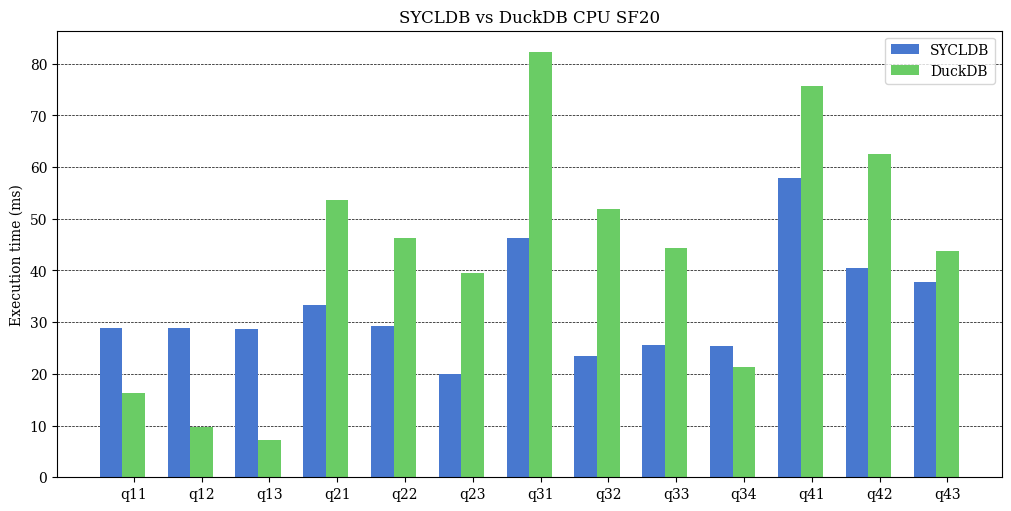

In [218]:
labels_mappings = {
    'cpu_s20_xpu_avg': 'SYCLDB',
    'duckdb_s20_xpu_avg': 'DuckDB',
}
plot_data(comparison_cpu, labels_mappings, title='SYCLDB vs DuckDB CPU SF20')

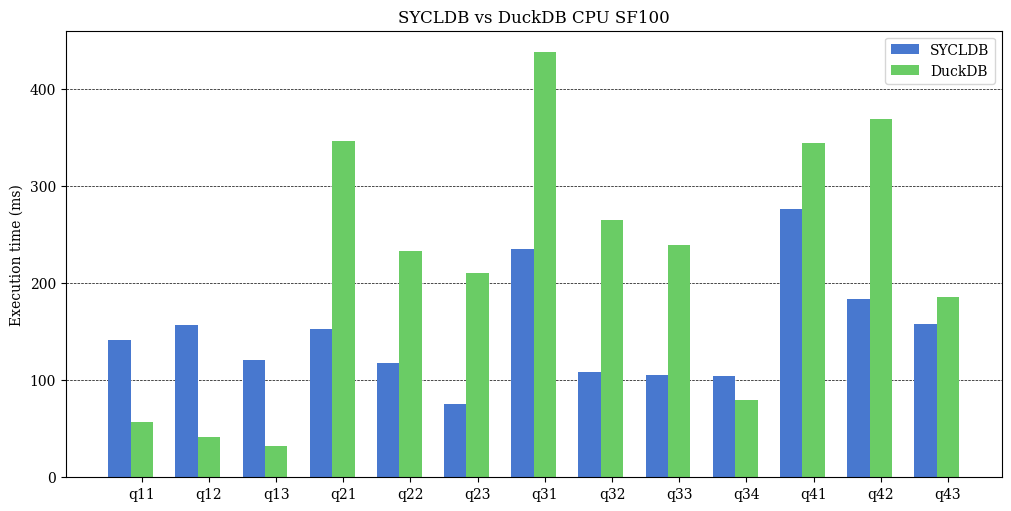

In [219]:
labels_mappings = {
    'cpu_s100_xpu_avg': 'SYCLDB',
    'duckdb_s100_xpu_avg': 'DuckDB',
}
plot_data(comparison_cpu, labels_mappings, title='SYCLDB vs DuckDB CPU SF100')

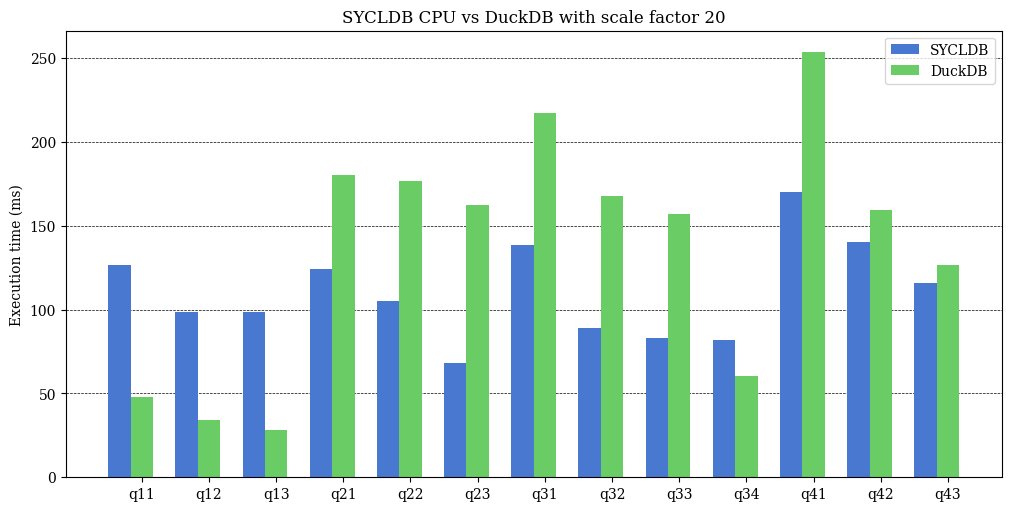

In [220]:
labels_mapping = {
    'cpu_s20_bonette_avg': 'SYCLDB',
    'duckdb_s20_bonette_avg': 'DuckDB',
}

plot_data(comparison_cpu, labels_mapping, title='SYCLDB CPU vs DuckDB with scale factor 20')

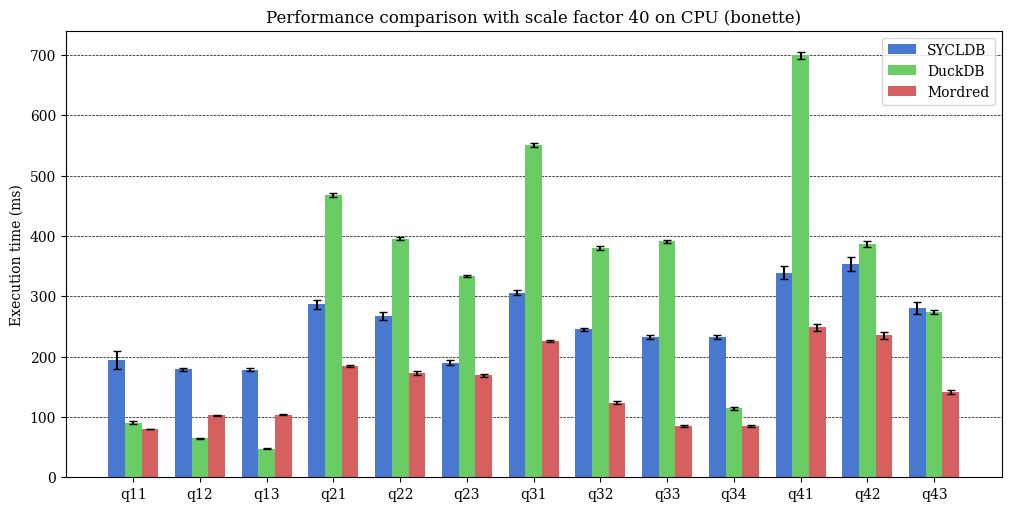

In [221]:
labels_mapping = {
    'cpu_s40_bonette_avg': 'SYCLDB',
    'duckdb_s40_bonette_avg': 'DuckDB',
    'mordred_s40_bonette_avg': 'Mordred',
}

plot_data(comparison_cpu, labels_mapping, title='Performance comparison with scale factor 40 on CPU (bonette)')

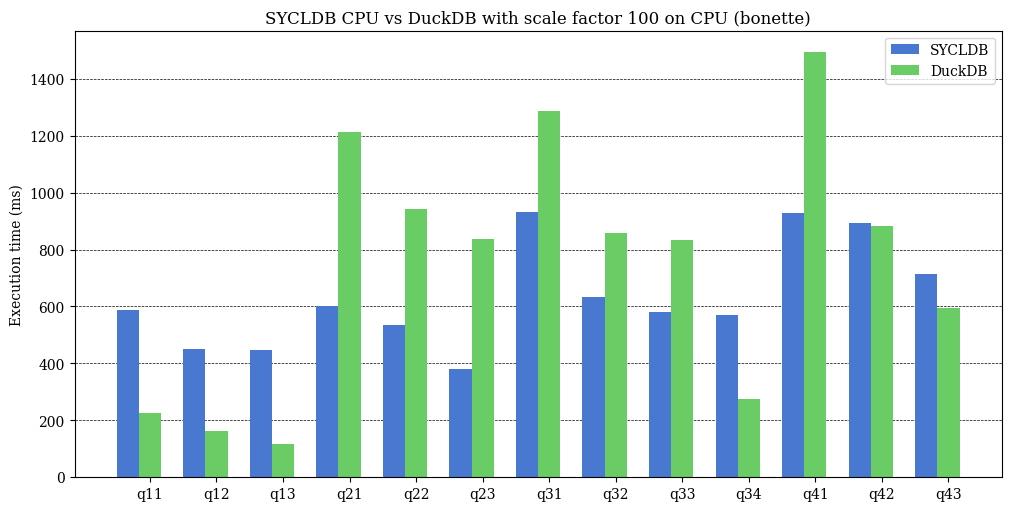

In [222]:
labels_mapping = {
    'cpu_s100_bonette_avg': 'SYCLDB',
    'duckdb_s100_bonette_avg': 'DuckDB',
}

plot_data(comparison_cpu, labels_mapping, title='SYCLDB CPU vs DuckDB with scale factor 100 on CPU (bonette)')

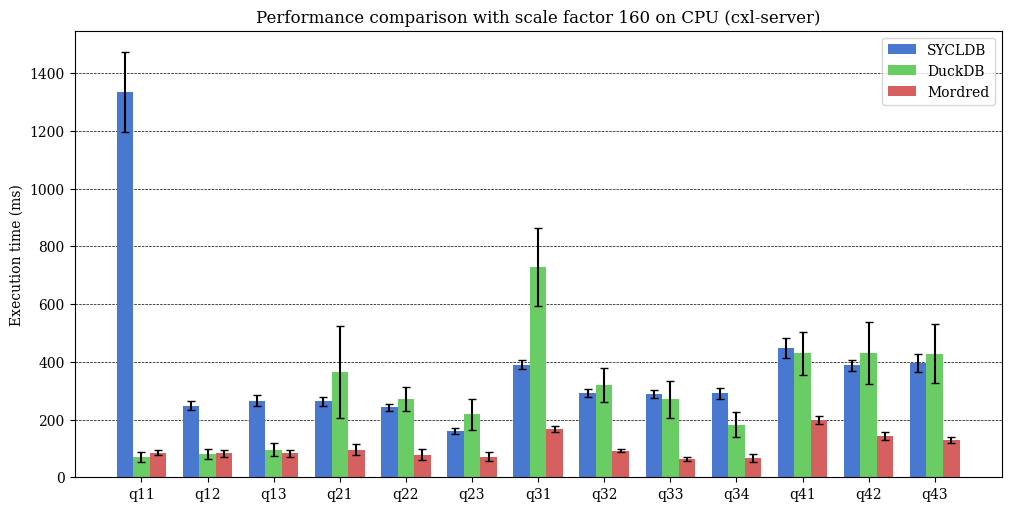

In [223]:
labels_mapping = {
    'cpu_s160_avg': 'SYCLDB',
    'duckdb_s160_avg': 'DuckDB',
    'mordred_s160_avg': 'Mordred',
}

plot_data(comparison_cpu, labels_mapping, title='Performance comparison with scale factor 160 on CPU (cxl-server)')

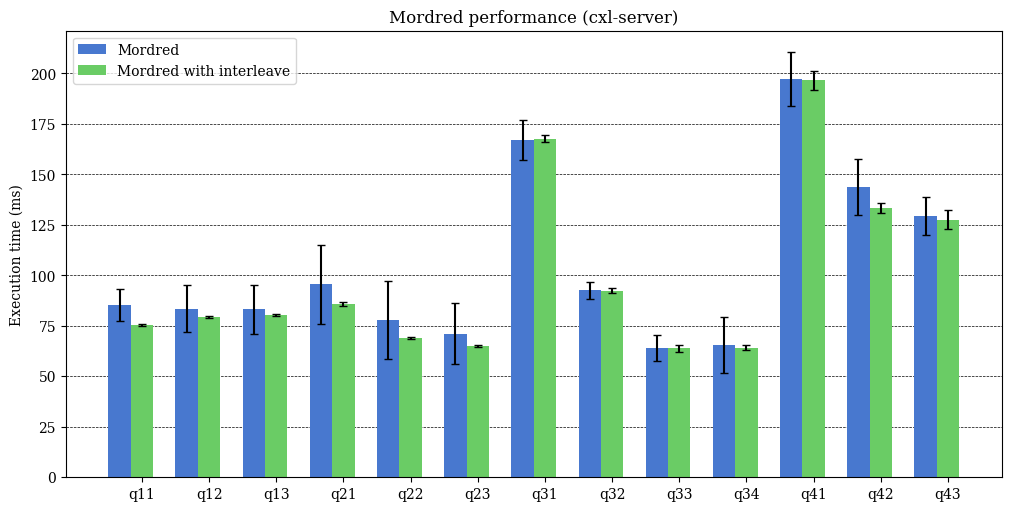

In [224]:
labels_mapping = {
    'mordred_s160_avg': 'Mordred',
    'mordred_s160_2_avg': 'Mordred with interleave',
}

plot_data(comparison_cpu, labels_mapping, title='Mordred performance (cxl-server)')

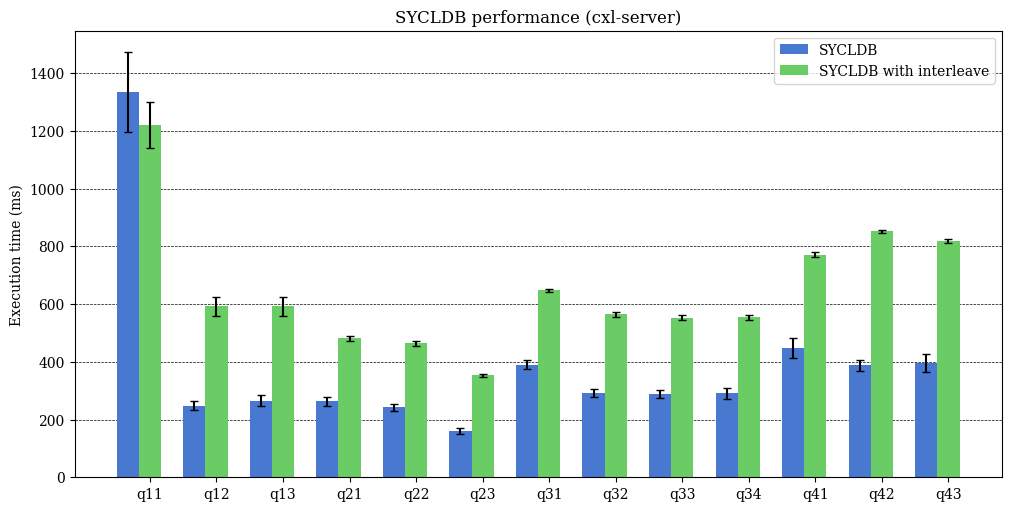

In [225]:
labels_mapping = {
    'cpu_s160_avg': 'SYCLDB',
    'cpu_s160_2_avg': 'SYCLDB with interleave',
}

plot_data(comparison_cpu, labels_mapping, title='SYCLDB performance (cxl-server)')

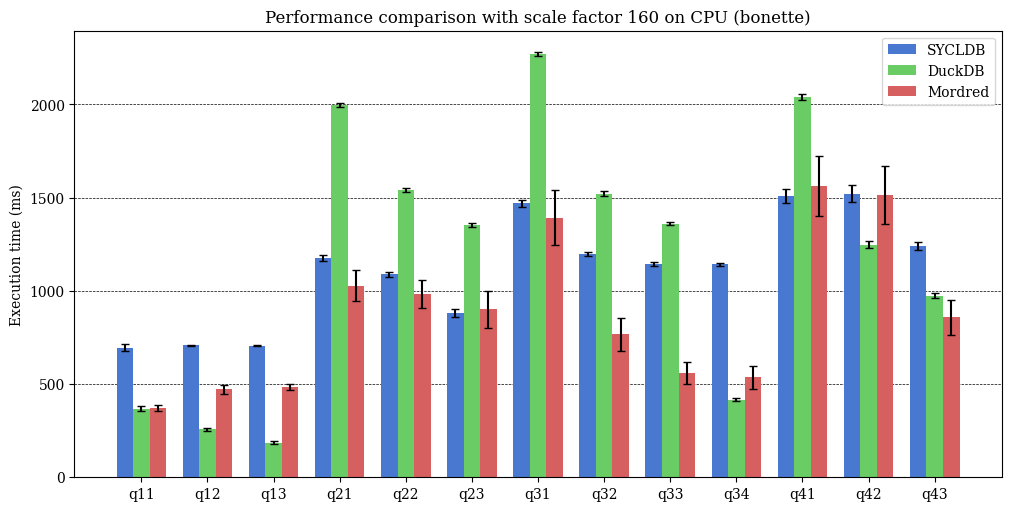

In [226]:
labels_mapping = {
    'cpu_s160_bonette_avg': 'SYCLDB',
    'duckdb_s160_bonette_avg': 'DuckDB',
    'mordred_s160_bonette_avg': 'Mordred',
}

plot_data(comparison_cpu, labels_mapping, title='Performance comparison with scale factor 160 on CPU (bonette)')

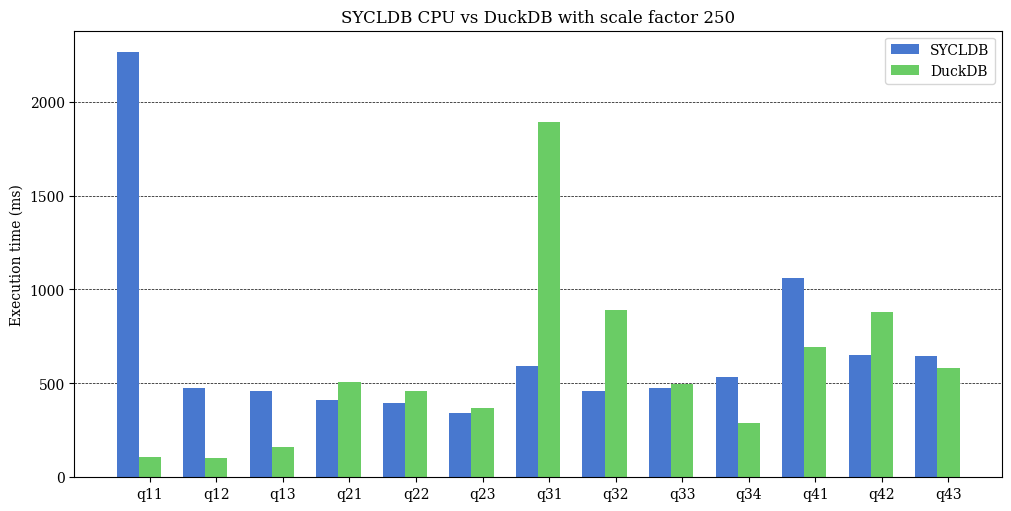

In [227]:
labels_mapping = {
    'cpu_s250_avg': 'SYCLDB',
    'duckdb_s250_avg': 'DuckDB',
}

plot_data(comparison_cpu, labels_mapping, title='SYCLDB CPU vs DuckDB with scale factor 250')

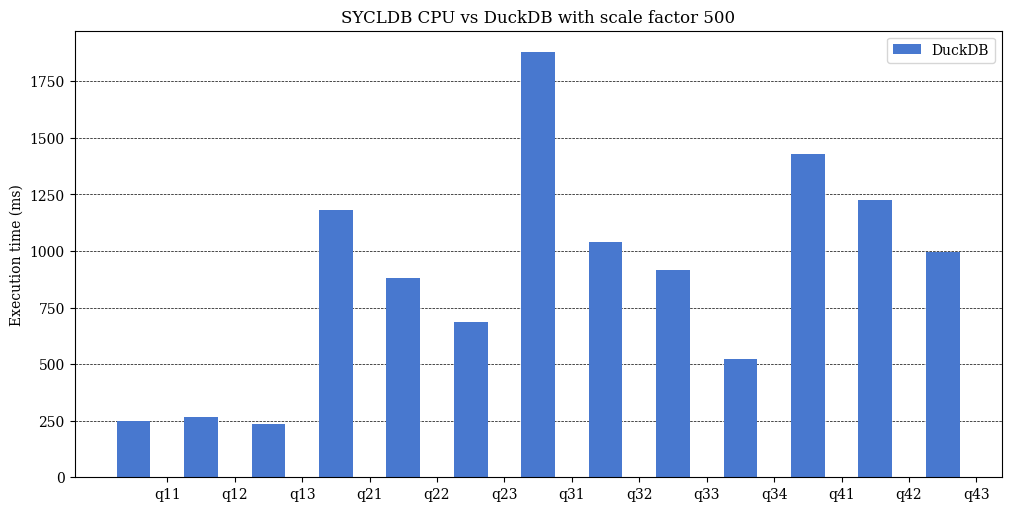

In [228]:
labels_mapping = {
    # 'cpu_ete_s500_avg': 'SYCLDB',
    'duckdb_s500_avg': 'DuckDB',
}

plot_data(comparison_cpu, labels_mapping, title='SYCLDB CPU vs DuckDB with scale factor 500')

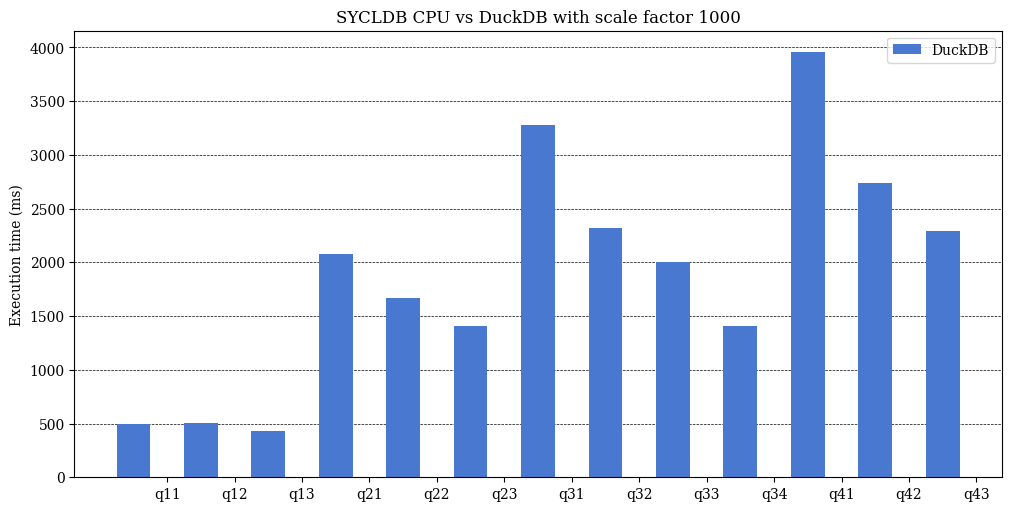

In [229]:
labels_mapping = {
    # 'cpu_ete_s1000_avg': 'SYCLDB',
    'duckdb_s1000_avg': 'DuckDB',
}

plot_data(comparison_cpu, labels_mapping, title='SYCLDB CPU vs DuckDB with scale factor 1000')

In [230]:
hybrid_results = pd.DataFrame()

for q in queries:
    cpu_s20_df = pd.read_csv(f'{q}-performance-cpu-s20.log', header=None, names=['execution_time_ms'])

    hybrid_s20_df = pd.read_csv(f'{q}-performance-hybrid-s20.log', header=None, names=['execution_time_ms'])
    hybrid_s40_df = pd.read_csv(f'{q}-performance-hybrid-s40.log', header=None, names=['execution_time_ms'])

    hybrid_s40_multigpu_df = pd.read_csv(f'{q}-performance-hybrid-multigpu-s40.log', header=None, names=['execution_time_ms'])

    hybrid_s160_cxl_df = pd.read_csv(f'{q}-performance-hybrid-cxl-s160.log', header=None, names=['execution_time_ms'])

    hybrid_mordred_s160_df = pd.read_csv(f'{q}-mordred-hybrid-s160.log', header=None, names=['execution_time_ms'])

    hybrid_results[f'{q}_hybrid_s20'] = hybrid_s20_df['execution_time_ms']
    hybrid_results[f'{q}_hybrid_s40'] = hybrid_s40_df['execution_time_ms']

    hybrid_results[f'{q}_hybrid_multigpu_s40'] = hybrid_s40_multigpu_df['execution_time_ms']

    hybrid_results[f'{q}_hybrid_s160_cxl'] = hybrid_s160_cxl_df['execution_time_ms']

    hybrid_results[f'{q}_hybrid_mordred_s160'] = hybrid_mordred_s160_df['execution_time_ms']
    
    hybrid_results[f'{q}_cpu_s20'] = cpu_s20_df['execution_time_ms']

    hybrid_results[f'{q}_cxl_cpu_s160'] = cpu_results[f'{q}_cpu_s160'] 

    hybrid_results[f'{q}_mordred_cpu_s160'] = cpu_results[f'{q}_mordred_s160']

hybrid_results[1:].describe()

/tmp/ipykernel_97181/1175636200.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  hybrid_results[f'{q}_hybrid_mordred_s160'] = hybrid_mordred_s160_df['execution_time_ms']
/tmp/ipykernel_97181/1175636200.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  hybrid_results[f'{q}_cpu_s20'] = cpu_s20_df['execution_time_ms']
/tmp/ipykernel_97181/1175636200.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all col

,q11_hybrid_s20,q11_hybrid_s40,q11_hybrid_multigpu_s40,q11_hybrid_s160_cxl,q11_hybrid_mordred_s160,q11_cpu_s20,q11_cxl_cpu_s160,q11_mordred_cpu_s160,q12_hybrid_s20,q12_hybrid_s40,...,q42_cxl_cpu_s160,q42_mordred_cpu_s160,q43_hybrid_s20,q43_hybrid_s40,q43_hybrid_multigpu_s40,q43_hybrid_s160_cxl,q43_hybrid_mordred_s160,q43_cpu_s20,q43_cxl_cpu_s160,q43_mordred_cpu_s160
count,99.00000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,...,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,114.74897,203.583939,201.114333,1399.973737,115.885364,126.894737,1334.989091,85.240603,85.540647,147.059798,...,387.418626,143.718717,266.693657,177.391758,213.535091,167.444232,46.817691,115.856586,396.155273,129.283111
std,2.90982,6.612326,7.886851,143.484796,1.340009,1.917171,138.230294,7.850522,2.346093,2.485230,...,18.322345,14.056856,14.040518,24.446578,15.389033,49.653543,1.015781,1.296912,31.417228,9.507504
min,110.22900,201.139000,197.602000,1337.830000,114.076000,125.306000,1230.090000,82.292600,83.286300,145.482000,...,350.153000,137.093000,243.221000,169.669000,205.291000,135.454000,45.172800,114.247000,358.647000,114.305000
25%,112.91200,201.574000,197.983000,1348.360000,114.699500,125.788000,1274.835000,83.611450,84.424800,145.867500,...,372.260000,139.436500,254.606000,170.672000,207.587500,140.565500,46.203350,114.910000,374.329000,122.498500
50%,113.63300,202.114000,198.591000,1354.800000,115.350000,126.245000,1291.680000,84.057200,84.840600,145.993000,...,387.886000,140.356000,266.466000,171.361000,208.926000,157.068000,46.557700,115.454000,390.790000,127.920000
75%,115.81550,203.584500,201.291000,1368.230000,117.128500,127.309500,1323.765000,84.778500,85.550750,147.173500,...,395.185000,141.649500,276.549500,172.563500,211.656000,164.074500,47.190150,116.455500,410.177000,132.407500
max,124.32100,265.507000,259.739000,2010.400000,118.731000,138.078000,1830.560000,140.801000,97.384700,164.172000,...,443.183000,219.767000,299.616000,326.135000,290.794000,351.613000,50.735100,121.816000,583.156000,171.114000


In [231]:
comparison_hybrid = []

for q in queries[3:]:
    cpu_s20_avg = hybrid_results[f'{q}_cpu_s20'].min()

    hybrid_s20_avg = hybrid_results[f'{q}_hybrid_s20'].min()
    hybrid_s40_avg = hybrid_results[f'{q}_hybrid_s40'].min()

    hybrid_s40_multigpu_avg = hybrid_results[f'{q}_hybrid_multigpu_s40'].min()

    hybrid_s160_cxl_avg = hybrid_results[f'{q}_hybrid_s160_cxl'].min()

    hybrid_mordred_s160_avg = hybrid_results[f'{q}_hybrid_mordred_s160'].min()

    cpu_s160_avg = hybrid_results[f'{q}_cxl_cpu_s160'].min()

    cpu_mordred_s160_avg = hybrid_results[f'{q}_mordred_cpu_s160'].min()

    comparison_hybrid.append({
        'query': q,

        'cpu_s20_avg': cpu_s20_avg,

        'hybrid_s20_avg': hybrid_s20_avg,
        'hybrid_s40_avg': hybrid_s40_avg,

        'hybrid_multigpu_s40_avg': hybrid_s40_multigpu_avg,

        'hybrid_s160_cxl_avg': hybrid_s160_cxl_avg,

        'hybrid_mordred_s160_avg': hybrid_mordred_s160_avg,

        'cpu_s160_avg': cpu_s160_avg,

        'cpu_mordred_s160_avg': cpu_mordred_s160_avg,
    })

comparison_hybrid = pd.DataFrame(comparison_hybrid)
comparison_hybrid

,query,cpu_s20_avg,hybrid_s20_avg,hybrid_s40_avg,hybrid_multigpu_s40_avg,hybrid_s160_cxl_avg,hybrid_mordred_s160_avg,cpu_s160_avg,cpu_mordred_s160_avg
0,q21,117.8190,176.585,167.503,245.870,123.2580,48.9865,243.010,89.8822
1,q22,101.6080,168.974,142.758,212.412,72.6119,47.2634,225.315,71.8547
2,q23,65.4838,120.354,120.271,200.142,56.7296,35.0468,147.025,66.9024
3,q31,135.6750,233.982,237.467,348.238,321.4050,182.0750,357.174,160.9110
4,q32,87.1203,213.971,138.249,206.708,78.1188,33.2031,277.715,88.7767
5,q33,80.9945,214.652,127.504,150.708,64.2334,26.2314,269.788,60.0323
6,q34,80.0809,212.548,132.482,140.940,77.6035,23.6229,271.838,59.2888
7,q41,165.7070,209.514,220.987,306.691,326.9870,371.2890,390.975,187.6930
8,q42,137.8690,252.118,187.006,277.523,155.8100,68.2902,350.153,137.0930
9,q43,114.2470,243.221,169.669,205.291,135.4540,45.1728,358.647,114.3050


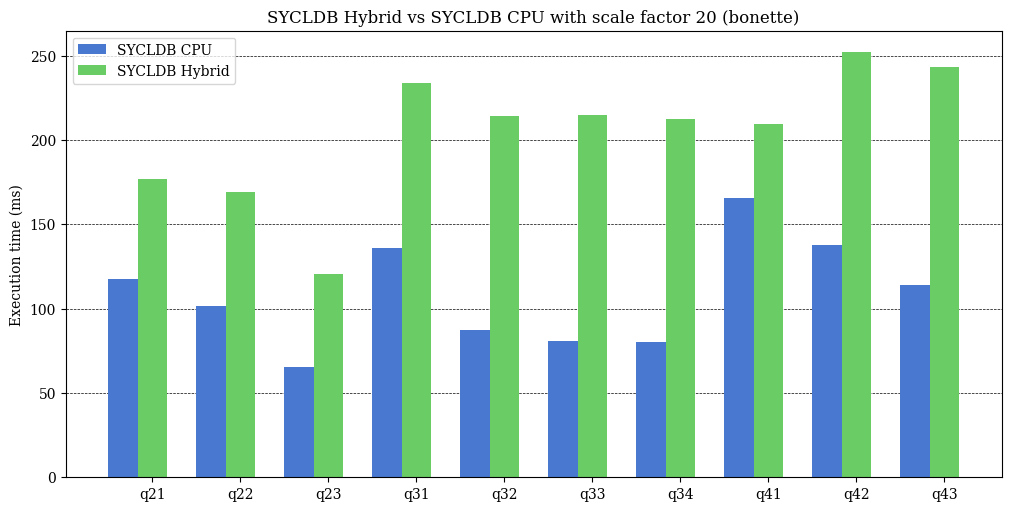

In [232]:
labels_mapping = {
    'cpu_s20_avg': 'SYCLDB CPU',
    'hybrid_s20_avg': 'SYCLDB Hybrid',
}

plot_data(comparison_hybrid, labels_mapping, title='SYCLDB Hybrid vs SYCLDB CPU with scale factor 20 (bonette)')

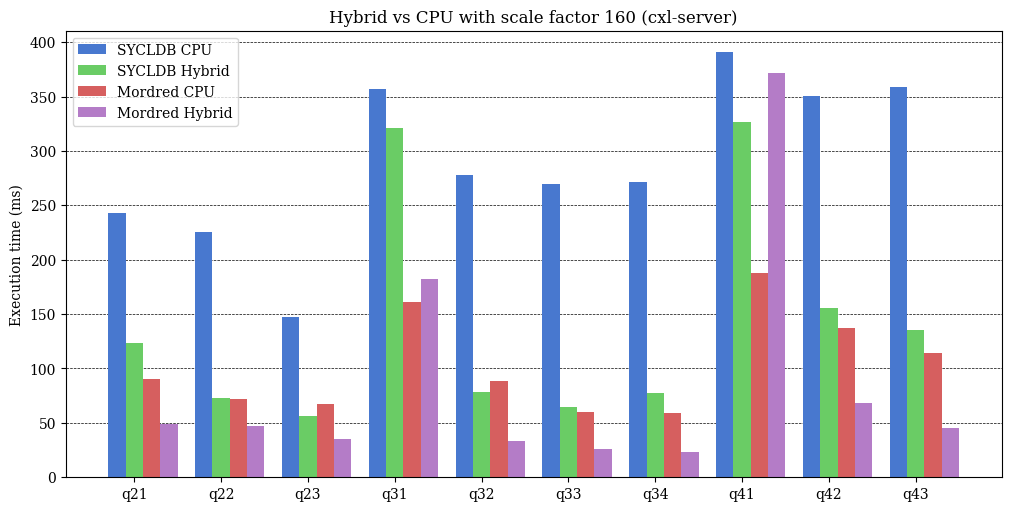

In [233]:
labels_mapping = {
    'cpu_s160_avg': 'SYCLDB CPU',
    'hybrid_s160_cxl_avg': 'SYCLDB Hybrid',
    'cpu_mordred_s160_avg': 'Mordred CPU',
    'hybrid_mordred_s160_avg': 'Mordred Hybrid',
}

plot_data(comparison_hybrid, labels_mapping, title='Hybrid vs CPU with scale factor 160 (cxl-server)')

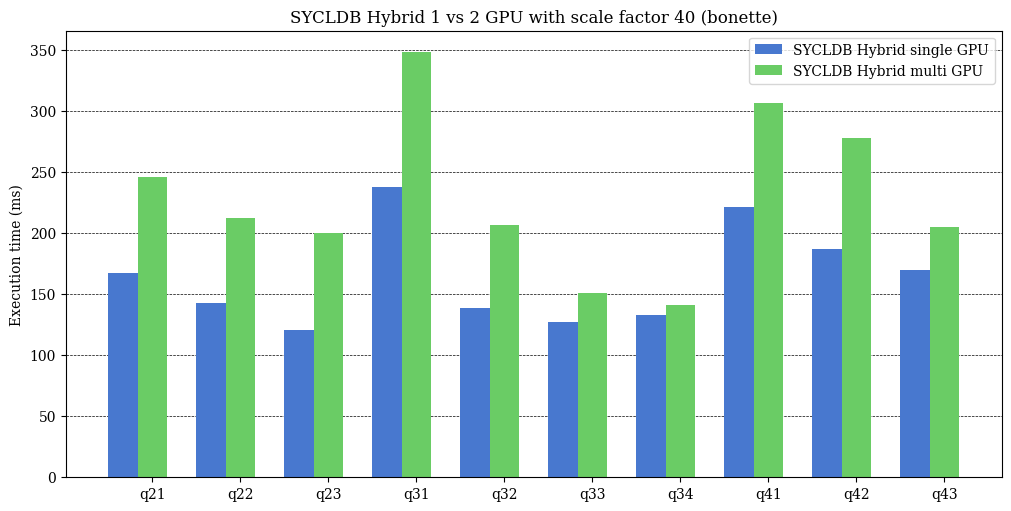

In [234]:
labels_mapping = {
    'hybrid_s40_avg': 'SYCLDB Hybrid single GPU',
    'hybrid_multigpu_s40_avg': 'SYCLDB Hybrid multi GPU',
}

plot_data(comparison_hybrid, labels_mapping, title='SYCLDB Hybrid 1 vs 2 GPU with scale factor 40 (bonette)')

In [235]:
mordred_comp_results = pd.DataFrame()

for q in queries:
    cpu_s40_df = pd.read_csv(f'{q}-performance-segments-cxl-cpu-s40.log', header=None, names=['execution_time_ms'])
    gpu_s40_df = pd.read_csv(f'{q}-performance-segments-cxl-gpu-s40.log', header=None, names=['execution_time_ms'])
    hybrid_s40_df = pd.read_csv(f'{q}-performance-segments-cxl-hybrid-s40.log', header=None, names=['execution_time_ms'])

    mordred_cpu_s40_df = pd.read_csv(f'{q}-mordred-cxl-cpu-s40.log', header=None, names=['execution_time_ms'])
    mordred_gpu_s40_df = pd.read_csv(f'{q}-mordred-cxl-gpu-s40.log', header=None, names=['execution_time_ms'])
    mordred_hybrid_s40_df = pd.read_csv(f'{q}-mordred-cxl-hybrid-s40.log', header=None, names=['execution_time_ms'])

    mordred_comp_results[f'{q}_cpu_s40'] = cpu_s40_df['execution_time_ms']
    mordred_comp_results[f'{q}_gpu_s40'] = gpu_s40_df['execution_time_ms']
    mordred_comp_results[f'{q}_hybrid_s40'] = hybrid_s40_df['execution_time_ms']

    mordred_comp_results[f'{q}_mordred_cpu_s40'] = mordred_cpu_s40_df['execution_time_ms']
    mordred_comp_results[f'{q}_mordred_gpu_s40'] = mordred_gpu_s40_df['execution_time_ms']
    mordred_comp_results[f'{q}_mordred_hybrid_s40'] = mordred_hybrid_s40_df['execution_time_ms']

In [236]:
comparison_mordred = []

for q in queries[3:]:
    cpu_s40_avg = mordred_comp_results[f'{q}_cpu_s40'].min()
    gpu_s40_avg = mordred_comp_results[f'{q}_gpu_s40'].min()
    hybrid_s40_avg = mordred_comp_results[f'{q}_hybrid_s40'].min()

    mordred_cpu_s40_avg = mordred_comp_results[f'{q}_mordred_cpu_s40'].min()
    mordred_gpu_s40_avg = mordred_comp_results[f'{q}_mordred_gpu_s40'].min()
    mordred_hybrid_s40_avg = mordred_comp_results[f'{q}_mordred_hybrid_s40'].min()

    comparison_mordred.append({
        'query': q,
        'cpu_s40_avg': cpu_s40_avg,
        'gpu_s40_avg': gpu_s40_avg,
        'hybrid_s40_avg': hybrid_s40_avg,
        'mordred_cpu_s40_avg': mordred_cpu_s40_avg,
        'mordred_gpu_s40_avg': mordred_gpu_s40_avg,
        'mordred_hybrid_s40_avg': mordred_hybrid_s40_avg,

        'sycldb_gpu_speedup': (cpu_s40_avg - gpu_s40_avg) / cpu_s40_avg * 100,
        'sycldb_hybrid_speedup': (cpu_s40_avg - hybrid_s40_avg) / cpu_s40_avg * 100,
        'mordred_gpu_speedup': (mordred_cpu_s40_avg - mordred_gpu_s40_avg) / mordred_cpu_s40_avg * 100,
        'mordred_hybrid_speedup': (mordred_cpu_s40_avg - mordred_hybrid_s40_avg) / mordred_cpu_s40_avg * 100,
    })

comparison_mordred = pd.DataFrame(comparison_mordred)

comparison_mordred[['query', 'sycldb_gpu_speedup', 'sycldb_hybrid_speedup', 'mordred_gpu_speedup', 'mordred_hybrid_speedup']]

,query,sycldb_gpu_speedup,sycldb_hybrid_speedup,mordred_gpu_speedup,mordred_hybrid_speedup
0,q21,91.792404,38.911956,69.774318,42.552231
1,q22,94.130301,53.893881,64.154602,42.249856
2,q23,91.716412,49.029523,61.663404,46.317889
3,q31,90.502131,12.536559,79.487218,-15.554173
4,q32,94.790794,53.838765,62.434463,57.022812
5,q33,96.265812,52.947834,47.841915,52.318123
6,q34,96.414811,44.171272,48.195131,55.254997
7,q41,90.588683,21.458077,78.672339,-100.884764
8,q42,91.428929,44.394334,67.809692,49.855486
9,q43,94.327524,46.548737,50.474173,50.872367


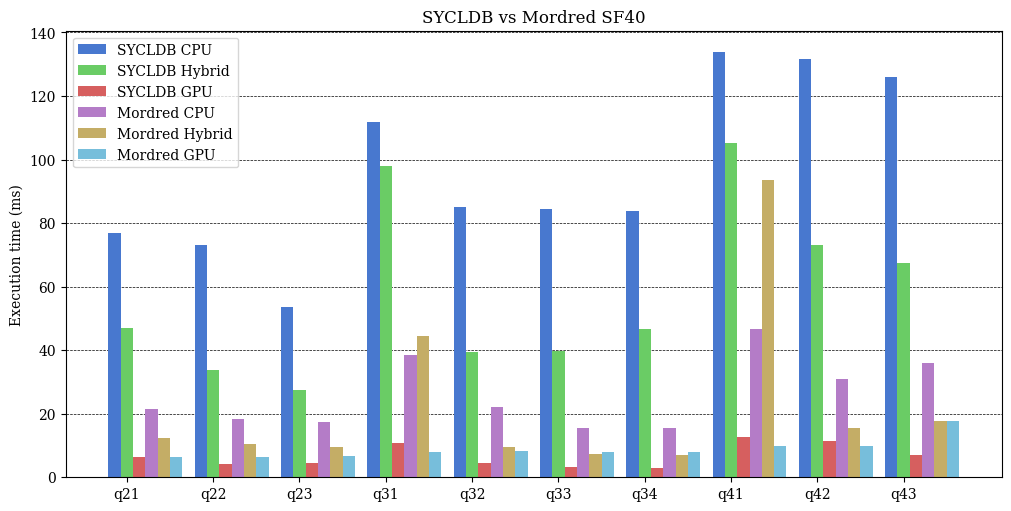

In [237]:
labels_mappings = {
    'cpu_s40_avg': 'SYCLDB CPU',
    'hybrid_s40_avg': 'SYCLDB Hybrid',
    'gpu_s40_avg': 'SYCLDB GPU',
    'mordred_cpu_s40_avg': 'Mordred CPU',
    'mordred_hybrid_s40_avg': 'Mordred Hybrid',
    'mordred_gpu_s40_avg': 'Mordred GPU',
}
plot_data(comparison_mordred, labels_mappings, title='SYCLDB vs Mordred SF40')

In [238]:
segment_size_results = pd.DataFrame()

segment_sizes_s100 = (1, 4, 16, 64, 256, 1024)

for q in queries:
    for s in segment_sizes_s100:
        df_s100 = pd.read_csv(f'{q}-performance-segments-cxl-{s}M-s100.log', header=None, names=['execution_time_ms'])
        df_nofusion_s100 = pd.read_csv(f'{q}-performance-segments-cxl-{s}M-s100-nofusion.log', header=None, names=['execution_time_ms'])
        segment_size_results[f'{q}_s100_{s}M'] = df_s100['execution_time_ms']
        segment_size_results[f'{q}_nofusion_s100_{s}M'] = df_nofusion_s100['execution_time_ms']
        

segment_size_results[1:].describe()

/tmp/ipykernel_97181/77398440.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  segment_size_results[f'{q}_s100_{s}M'] = df_s100['execution_time_ms']
/tmp/ipykernel_97181/77398440.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  segment_size_results[f'{q}_nofusion_s100_{s}M'] = df_nofusion_s100['execution_time_ms']


,q11_s100_1M,q11_nofusion_s100_1M,q11_s100_4M,q11_nofusion_s100_4M,q11_s100_16M,q11_nofusion_s100_16M,q11_s100_64M,q11_nofusion_s100_64M,q11_s100_256M,q11_nofusion_s100_256M,...,q43_s100_4M,q43_nofusion_s100_4M,q43_s100_16M,q43_nofusion_s100_16M,q43_s100_64M,q43_nofusion_s100_64M,q43_s100_256M,q43_nofusion_s100_256M,q43_s100_1024M,q43_nofusion_s100_1024M
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,...,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,176.887023,125.070931,59.000371,41.187196,24.568392,31.636673,24.135145,38.500586,15.851320,38.630885,...,127.078001,30.854380,73.393428,23.590624,101.054689,27.035280,35.475937,26.654904,38.769638,60.515309
std,102.302535,32.975468,69.059632,13.079371,42.132945,5.581471,48.265419,1.047426,16.816171,0.528289,...,144.496960,10.683153,96.961675,3.687167,134.593001,1.135053,69.365633,0.932261,56.603441,0.680365
min,52.916300,72.173500,16.170000,25.844400,13.873400,26.581900,13.895100,37.900000,13.904700,38.265000,...,16.882600,22.059200,14.890000,21.499200,14.976500,26.246200,14.827600,25.994800,20.551200,60.130600
25%,92.140400,86.301400,20.313100,29.001650,14.215050,27.566650,14.033300,38.146750,14.002000,38.380000,...,29.149150,23.662200,16.132100,21.744000,15.163200,26.373750,14.953800,26.290600,21.214950,60.227400
50%,139.597000,143.053000,37.527900,36.714300,14.626800,28.807600,14.137900,38.304500,14.060400,38.497600,...,47.275500,24.707300,43.233400,22.043300,15.704500,26.584600,15.211300,26.516600,22.641000,60.402500
75%,293.977500,153.495500,51.015550,55.119450,14.924800,35.138700,14.449300,38.507800,14.186300,38.662700,...,294.929500,36.719150,60.299550,24.843550,258.715500,27.472050,20.845350,26.758500,39.632350,60.640150
max,377.655000,168.769000,310.459000,78.938400,243.717000,64.227200,271.795000,48.102000,181.440000,42.538800,...,487.111000,78.803300,371.669000,51.030200,466.729000,35.908500,372.902000,34.524600,393.752000,66.603000


In [239]:
comparison_segment_size = []

for s in segment_sizes_s100:
    segment_size_avgs = {}
    segment_size_stds = {}
    segment_size_mins = {}
    for q in queries:
        segment_size_avgs[f's100_{q}'] = segment_size_results[f'{q}_s100_{s}M'][1:].mean()
        segment_size_stds[f's100_{q}'] = segment_size_results[f'{q}_s100_{s}M'][1:].std()
        segment_size_mins[f's100_{q}'] = segment_size_results[f'{q}_s100_{s}M'].min()

        segment_size_avgs[f'nofusion_s100_{q}'] = segment_size_results[f'{q}_nofusion_s100_{s}M'][1:].mean()
        segment_size_stds[f'nofusion_s100_{q}'] = segment_size_results[f'{q}_nofusion_s100_{s}M'][1:].std()
        segment_size_mins[f'nofusion_s100_{q}'] = segment_size_results[f'{q}_nofusion_s100_{s}M'].min()

    comparison_segment_size.append({
        'segment_size': s,
        **{f'{col}_avg': avg for col, avg in segment_size_avgs.items()},
        **{f'{col}_std': std for col, std in segment_size_stds.items()},
        **{f'{col}_min': min_val for col, min_val in segment_size_mins.items()}
    })

comparison_segment_size = pd.DataFrame(comparison_segment_size)

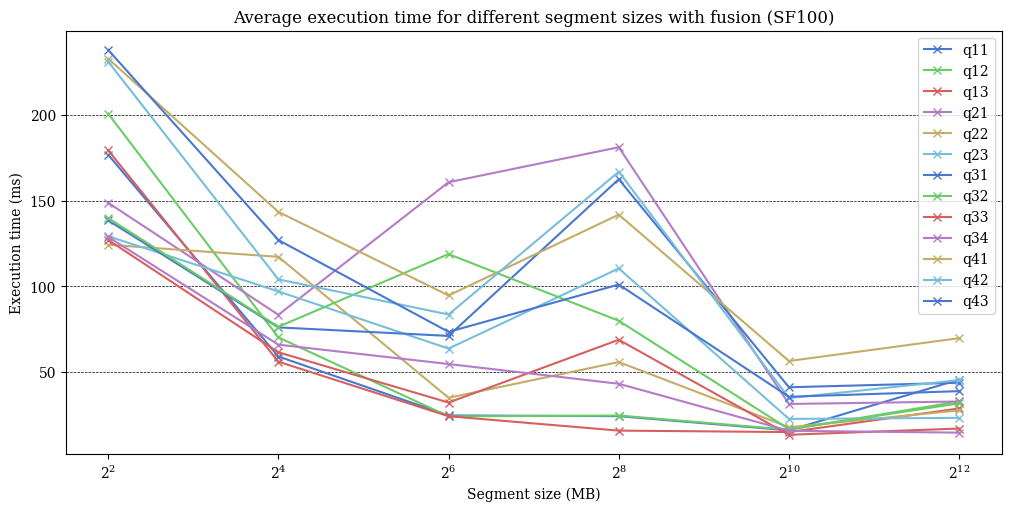

In [240]:
plot_segment_size_comparison(comparison_segment_size, 's100', 'avg', use_std=False, title='Average execution time for different segment sizes with fusion (SF100)')

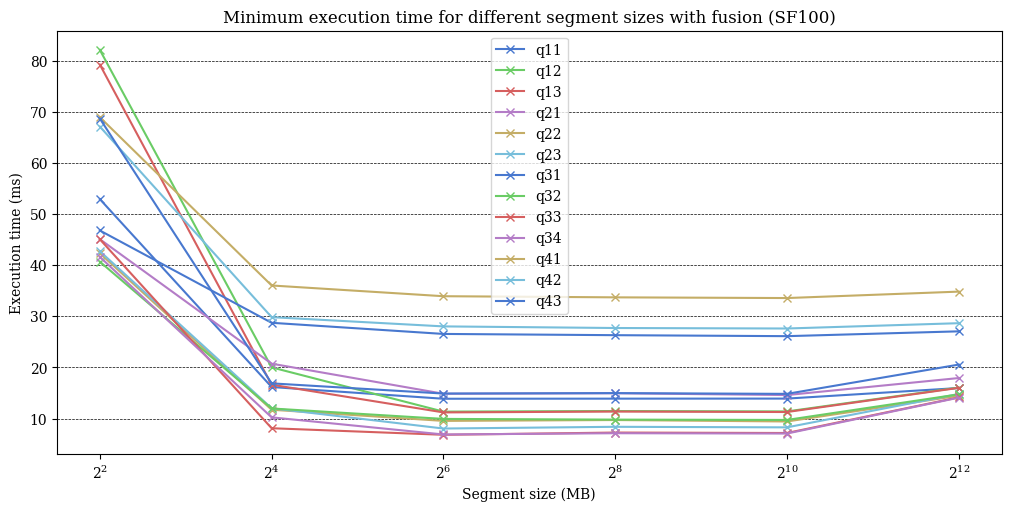

In [241]:
plot_segment_size_comparison(comparison_segment_size, 's100', 'min', use_std=False, title='Minimum execution time for different segment sizes with fusion (SF100)')

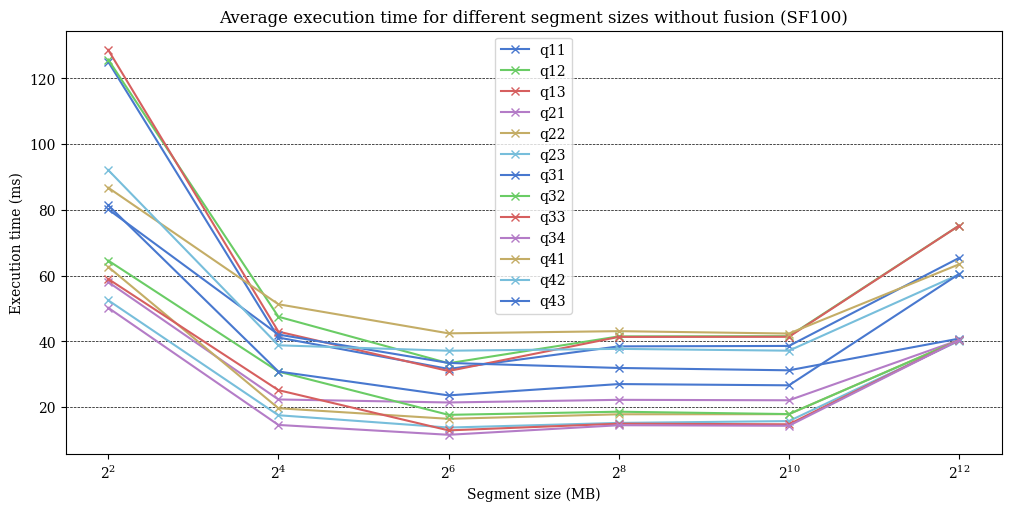

In [242]:
plot_segment_size_comparison(comparison_segment_size, 'nofusion_s100', 'avg', use_std=False, title='Average execution time for different segment sizes without fusion (SF100)')

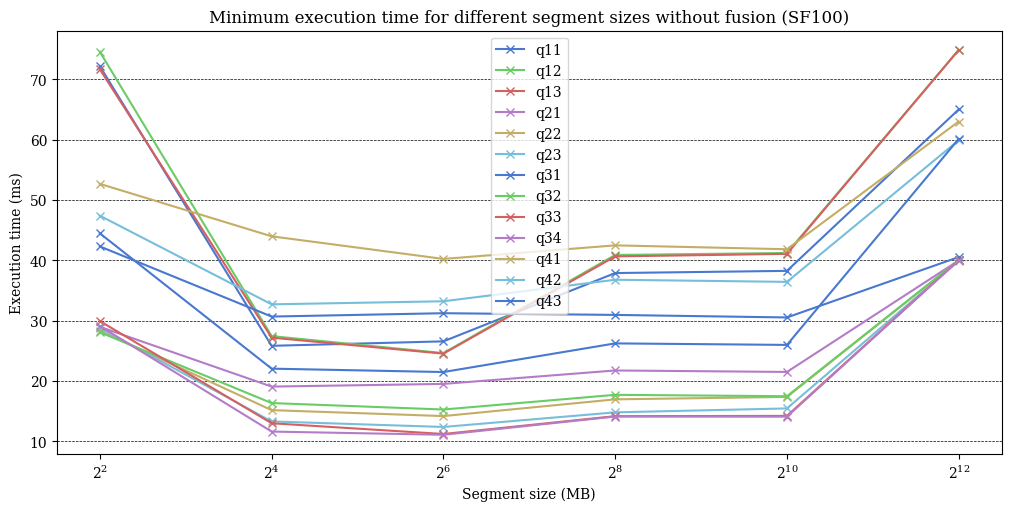

In [243]:
plot_segment_size_comparison(comparison_segment_size, 'nofusion_s100', 'min', use_std=False, title='Minimum execution time for different segment sizes without fusion (SF100)')

In [244]:
segment_size_results = pd.DataFrame()

segment_sizes_s20 = (1, 2, 4, 8, 16, 32, 64, 128)

for q in queries:
    for s in segment_sizes_s20:
        df_s20 = pd.read_csv(f'{q}-performance-segments-cxl-{s}M-s20.log', header=None, names=['execution_time_ms'])
        df_nofusion_s20 = pd.read_csv(f'{q}-performance-segments-cxl-{s}M-s20-nofusion.log', header=None, names=['execution_time_ms'])
        segment_size_results[f'{q}_s20_{s}M'] = df_s20['execution_time_ms']
        segment_size_results[f'{q}_nofusion_s20_{s}M'] = df_nofusion_s20['execution_time_ms']
        

segment_size_results[1:].describe()

/tmp/ipykernel_97181/1028067524.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  segment_size_results[f'{q}_s20_{s}M'] = df_s20['execution_time_ms']
/tmp/ipykernel_97181/1028067524.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  segment_size_results[f'{q}_nofusion_s20_{s}M'] = df_nofusion_s20['execution_time_ms']


,q11_s20_1M,q11_nofusion_s20_1M,q11_s20_2M,q11_nofusion_s20_2M,q11_s20_4M,q11_nofusion_s20_4M,q11_s20_8M,q11_nofusion_s20_8M,q11_s20_16M,q11_nofusion_s20_16M,...,q43_s20_8M,q43_nofusion_s20_8M,q43_s20_16M,q43_nofusion_s20_16M,q43_s20_32M,q43_nofusion_s20_32M,q43_s20_64M,q43_nofusion_s20_64M,q43_s20_128M,q43_nofusion_s20_128M
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,...,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,43.614647,30.101348,26.421054,14.221244,11.465922,6.247421,16.901376,5.882045,12.712429,6.985041,...,143.192781,4.777694,86.704307,5.468192,18.269012,5.003576,22.456299,5.143406,15.047956,5.198463
std,64.189313,14.278973,59.716378,7.531819,31.180445,1.331026,57.251674,2.093232,48.352517,0.480313,...,154.494762,0.804662,142.755066,2.184038,59.758700,0.283908,70.344179,0.489623,55.588935,0.469336
min,8.231220,14.067900,5.976910,7.722550,3.103930,5.292060,2.944510,4.895920,2.906930,5.520110,...,3.455630,4.203950,3.327980,4.323410,3.377930,4.731020,3.611110,4.779300,4.053650,4.886950
25%,15.086850,15.955000,6.913305,8.438565,3.467205,5.442860,2.992340,5.212340,2.941000,6.856440,...,5.370395,4.264000,3.587360,4.597500,3.485685,4.805450,3.757490,4.852185,4.129200,4.986140
50%,22.937700,25.907800,7.632220,9.616960,4.033600,5.671090,3.053730,5.549710,2.969120,6.965940,...,9.452280,4.360650,4.248330,4.959110,3.615770,4.887020,4.580240,4.962600,4.296410,5.067410
75%,38.370250,46.714950,16.425250,24.075650,5.107830,6.513435,3.297855,5.976600,3.066330,7.103510,...,306.504000,5.131975,143.048000,5.230885,4.342735,5.117555,7.140520,5.268340,5.604140,5.343570
max,347.530000,50.768700,279.958000,36.628300,167.797000,11.343800,268.721000,25.613100,306.994000,9.193590,...,471.414000,9.565220,458.981000,18.278200,353.730000,6.136340,368.560000,7.277290,407.554000,9.011140


In [245]:
comparison_segment_size = []

for s in segment_sizes_s20:
    segment_size_avgs = {}
    segment_size_stds = {}
    segment_size_mins = {}
    for q in queries:
        segment_size_avgs[f's20_{q}'] = segment_size_results[f'{q}_s20_{s}M'][1:].mean()
        segment_size_stds[f's20_{q}'] = segment_size_results[f'{q}_s20_{s}M'][1:].std()
        segment_size_mins[f's20_{q}'] = segment_size_results[f'{q}_s20_{s}M'].min()

        segment_size_avgs[f'nofusion_s20_{q}'] = segment_size_results[f'{q}_nofusion_s20_{s}M'][1:].mean()
        segment_size_stds[f'nofusion_s20_{q}'] = segment_size_results[f'{q}_nofusion_s20_{s}M'][1:].std()
        segment_size_mins[f'nofusion_s20_{q}'] = segment_size_results[f'{q}_nofusion_s20_{s}M'].min()

    comparison_segment_size.append({
        'segment_size': s,
        **{f'{col}_avg': avg for col, avg in segment_size_avgs.items()},
        **{f'{col}_std': std for col, std in segment_size_stds.items()},
        **{f'{col}_min': min_val for col, min_val in segment_size_mins.items()}
    })

comparison_segment_size = pd.DataFrame(comparison_segment_size)

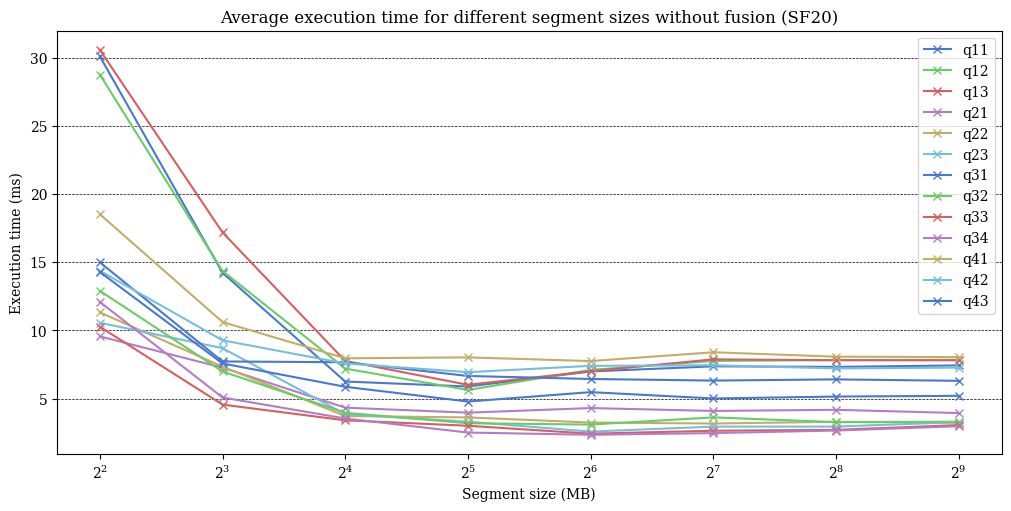

In [246]:
plot_segment_size_comparison(comparison_segment_size, 'nofusion_s20', 'avg', use_std=False, title='Average execution time for different segment sizes without fusion (SF20)')

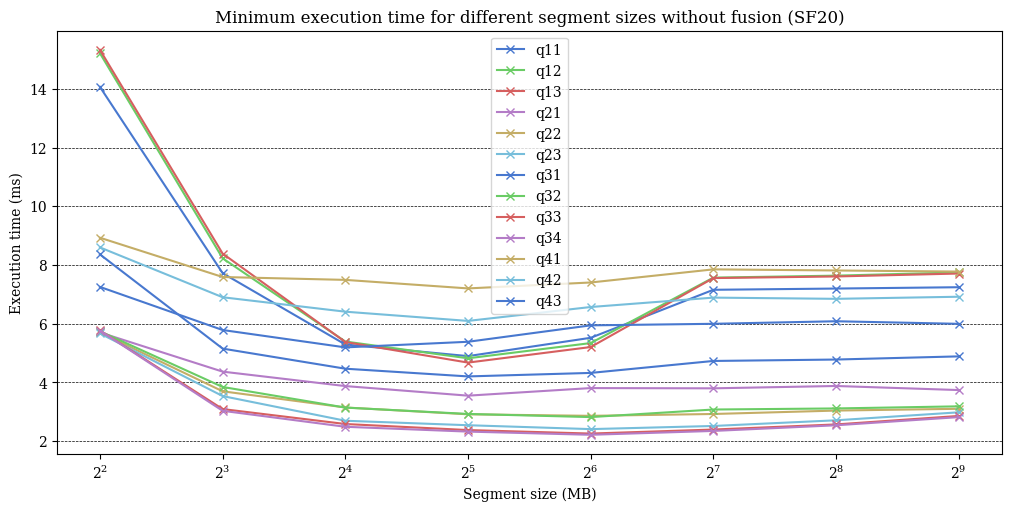

In [247]:
plot_segment_size_comparison(comparison_segment_size, 'nofusion_s20', 'min', use_std=False, title='Minimum execution time for different segment sizes without fusion (SF20)')

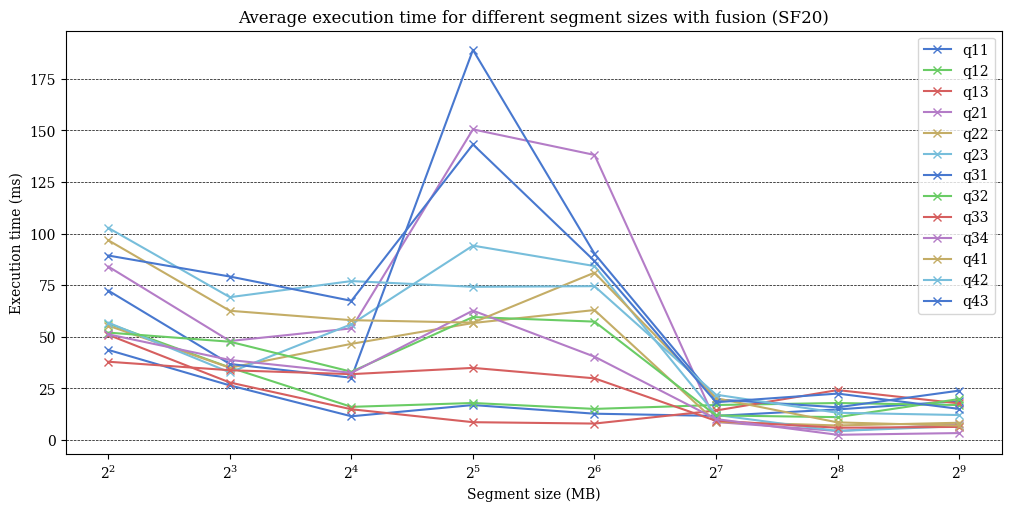

In [248]:
plot_segment_size_comparison(comparison_segment_size, 's20', 'avg', use_std=False, title='Average execution time for different segment sizes with fusion (SF20)')

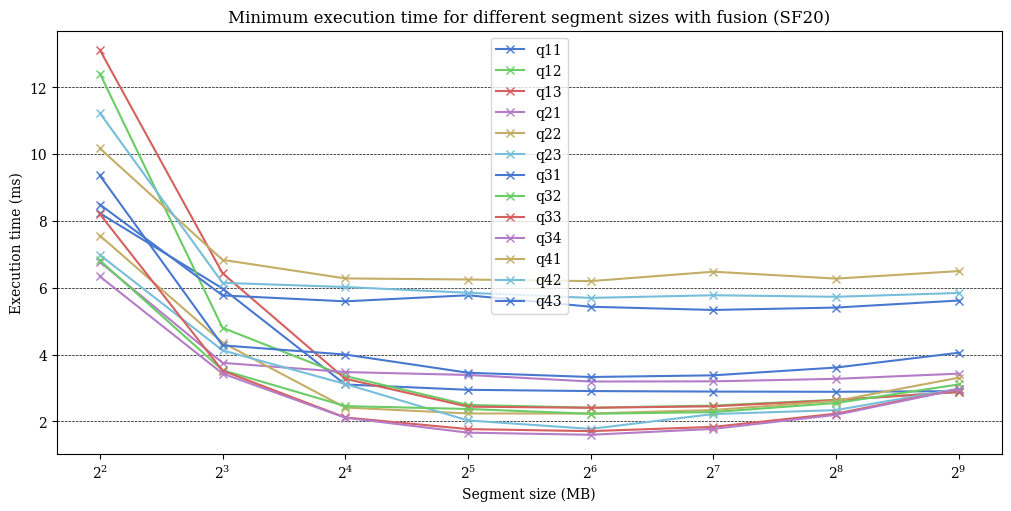

In [249]:
plot_segment_size_comparison(comparison_segment_size, 's20', 'min', use_std=False, title='Minimum execution time for different segment sizes with fusion (SF20)')

In [250]:
xpu_comparison_results = pd.DataFrame()

for q in queries:
    amd_s20_df = pd.read_csv(f'{q}-performance-xpu-s20-amd.log', header=None, names=['execution_time_ms'])
    intel_s20_df = pd.read_csv(f'{q}-performance-xpu-s20-intel.log', header=None, names=['execution_time_ms'])
    amd_s20_nofusion_df = pd.read_csv(f'{q}-performance-xpu-s20-amd-nofusion.log', header=None, names=['execution_time_ms'])
    intel_s20_nofusion_df = pd.read_csv(f'{q}-performance-xpu-s20-intel-nofusion.log', header=None, names=['execution_time_ms'])

    amd_s100_df = pd.read_csv(f'{q}-performance-xpu-s100-amd.log', header=None, names=['execution_time_ms'])
    amd_s100_nofusion_df = pd.read_csv(f'{q}-performance-xpu-s100-amd-nofusion.log', header=None, names=['execution_time_ms'])

    xpu_comparison_results[f'{q}_nvidia_s20'] = results_fusion_vs_nofusion[f'{q}_fusion_segments_s20']
    xpu_comparison_results[f'{q}_amd_s20'] = amd_s20_df['execution_time_ms']
    xpu_comparison_results[f'{q}_intel_s20'] = intel_s20_df['execution_time_ms']
    xpu_comparison_results[f'{q}_amd_s20_nofusion'] = amd_s20_nofusion_df['execution_time_ms']
    xpu_comparison_results[f'{q}_intel_s20_nofusion'] = intel_s20_nofusion_df['execution_time_ms']
    xpu_comparison_results[f'{q}_nvidia_s20_nofusion'] = results_fusion_vs_nofusion[f'{q}_nofusion_segments_s20']

    xpu_comparison_results[f'{q}_amd_s100'] = amd_s100_df['execution_time_ms']
    xpu_comparison_results[f'{q}_amd_s100_nofusion'] = amd_s100_nofusion_df['execution_time_ms']

xpu_comparison_results[1:].describe()

/tmp/ipykernel_97181/291533108.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  xpu_comparison_results[f'{q}_intel_s20_nofusion'] = intel_s20_nofusion_df['execution_time_ms']
/tmp/ipykernel_97181/291533108.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  xpu_comparison_results[f'{q}_nvidia_s20_nofusion'] = results_fusion_vs_nofusion[f'{q}_nofusion_segments_s20']
/tmp/ipykernel_97181/291533108.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which

,q11_nvidia_s20,q11_amd_s20,q11_intel_s20,q11_amd_s20_nofusion,q11_intel_s20_nofusion,q11_nvidia_s20_nofusion,q11_amd_s100,q11_amd_s100_nofusion,q12_nvidia_s20,q12_amd_s20,...,q42_amd_s100,q42_amd_s100_nofusion,q43_nvidia_s20,q43_amd_s20,q43_intel_s20,q43_amd_s20_nofusion,q43_intel_s20_nofusion,q43_nvidia_s20_nofusion,q43_amd_s100,q43_amd_s100_nofusion
count,99.000000,99.000000,99.000000,99.000000,99.00000,99.000000,99.000000,99.000000,99.000000,99.000000,...,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,17.372696,12.092537,52.694366,18.812108,20.51550,7.342125,32.112221,83.550458,14.411320,17.775720,...,329.368019,60.175235,16.974174,55.628927,124.094175,42.160361,15.961328,4.949667,117.649194,108.506833
std,46.739019,36.062452,39.547216,1.341116,0.43028,0.100319,65.227474,148.982321,43.332191,65.621484,...,474.112499,61.236596,59.108504,93.194720,104.093489,122.764663,0.287937,0.075408,174.153838,190.674794
min,3.120880,4.097820,28.341300,14.369600,19.88130,7.286250,13.779600,36.902900,3.359060,4.137950,...,45.413300,47.559900,4.750700,6.725170,43.171500,10.533500,15.256600,4.851500,26.871700,43.282100
25%,3.269065,4.509835,37.317900,18.108700,20.28055,7.308165,13.950700,38.419450,3.449305,4.987045,...,50.399750,47.665550,4.835305,8.097715,58.270800,10.757550,15.783150,4.920945,27.472250,43.411200
50%,3.312890,4.684880,38.656100,18.865600,20.45160,7.321320,14.182100,40.754700,3.518820,5.392920,...,110.939000,47.718400,4.913780,8.582430,60.641200,10.937500,15.968400,4.938800,28.823300,43.918200
75%,3.380775,4.920530,51.092500,19.586850,20.65495,7.336360,14.565150,42.233150,3.573830,5.968660,...,353.134500,47.793700,5.022810,9.529605,266.170500,13.065150,16.153650,4.959745,165.713000,44.119550
max,194.706000,198.414000,249.741000,23.852900,22.46500,7.955620,379.091000,850.677000,212.073000,546.448000,...,2150.990000,417.475000,411.135000,486.007000,394.226000,736.582000,16.670400,5.502940,783.251000,968.120000


In [251]:
comparison_xpu = []

for q in queries:
    nvidia_s20_min = xpu_comparison_results[f'{q}_nvidia_s20'].min()
    amd_s20_min = xpu_comparison_results[f'{q}_amd_s20'].min()
    intel_s20_min = xpu_comparison_results[f'{q}_intel_s20'].min()
    amd_nofusion_s20_min = xpu_comparison_results[f'{q}_amd_s20_nofusion'].min()
    intel_nofusion_s20_min = xpu_comparison_results[f'{q}_intel_s20_nofusion'].min()
    nvidia_nofusion_s20_min = xpu_comparison_results[f'{q}_nvidia_s20_nofusion'].min()

    amd_s100_min = xpu_comparison_results[f'{q}_amd_s100'].min()
    amd_nofusion_s100_min = xpu_comparison_results[f'{q}_amd_s100_nofusion'].min()

    comparison_xpu.append({
        'query': q,
        'nvidia_s20_min': nvidia_s20_min,
        'amd_s20_min': amd_s20_min,
        'intel_s20_min': intel_s20_min,
        'amd_nofusion_s20_min': amd_nofusion_s20_min,
        'intel_nofusion_s20_min': intel_nofusion_s20_min,
        'nvidia_nofusion_s20_min': nvidia_nofusion_s20_min,
        'amd_s100_min': amd_s100_min,
        'amd_nofusion_s100_min': amd_nofusion_s100_min,
    })

comparison_xpu = pd.DataFrame(comparison_xpu)

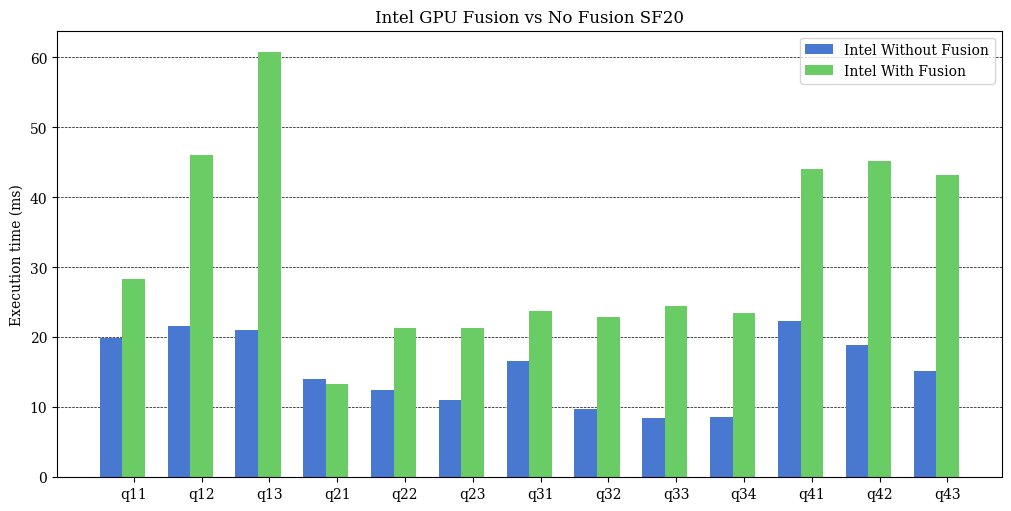

In [252]:
labels_mappings = {
    # 'nvidia_s20_min': 'NVIDIA fusion',
    # 'nvidia_nofusion_s20_min': 'NVIDIA no fusion',
    # 'amd_s20_min': 'AMD fusion',
    # 'amd_nofusion_s20_min': 'AMD no fusion',
    'intel_nofusion_s20_min': 'Intel Without Fusion',
    'intel_s20_min': 'Intel With Fusion',
}
plot_data(comparison_xpu, labels_mappings, title='Intel GPU Fusion vs No Fusion SF20')

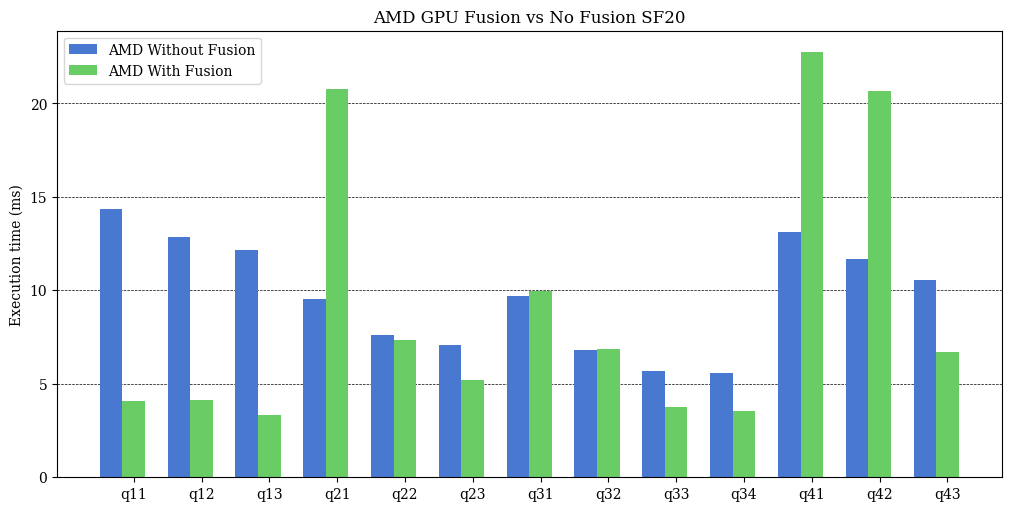

In [253]:
labels_mapping = {
    'amd_nofusion_s20_min': 'AMD Without Fusion',
    'amd_s20_min': 'AMD With Fusion',
}
plot_data(comparison_xpu, labels_mapping, title='AMD GPU Fusion vs No Fusion SF20')

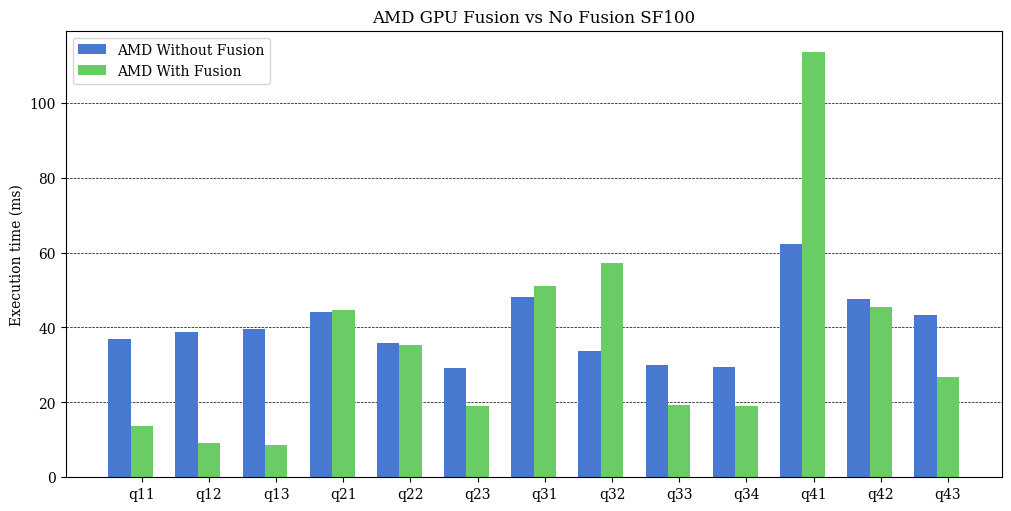

In [254]:
labels_mapping = {
    'amd_nofusion_s100_min': 'AMD Without Fusion',
    'amd_s100_min': 'AMD With Fusion',
}
plot_data(comparison_xpu, labels_mapping, title='AMD GPU Fusion vs No Fusion SF100')